<a href="https://colab.research.google.com/github/brunogk/Projeto-SOILINSIGHT/blob/main/Projeto_de_ML_corrigido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🌿 Carregamento de Bibliotecas Usadas no projeto

Organizar o ambiente de análise. Ao carregar `pandas`, garantimos a capacidade de manipular e estruturar dados tabulares, essencial para qualquer dataset. `numpy` nos oferece ferramentas para computações numéricas eficientes, frequentemente necessárias em cálculos estatísticos. As bibliotecas `matplotlib.pyplot` e `seaborn` são cruciais para a visualização de dados, permitindo-nos explorar tendências, distribuições e correlações de variáveis edafoclimáticas, que são a linguagem do solo e do clima. As configurações visuais (`plt.rcParams`, `sns.set_style`) asseguram que os gráficos serão claros, legíveis e profissionalmente apresentados, facilitando a comunicação de insights agronômicos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais necessárias
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


### 🚜 Carregamento e Visão Geral Inicial do Dataset


Carregamento do conjunto de dados `crop_recommendation.csv` diretamente de um repositório online do Kaeglle. O dataset, com **2200 linhas e 8  colunas**, representa um bom volume de amostras para o objetivo de recomendação de culturas. A visualização das primeiras 10 linhas (`df.head(10)`) é como uma primeira inspeção do solo: ela nos mostra as variáveis cruciais que descrevem as condições ideais para diferentes culturas, incluindo níveis de Nitrogênio (N), Fósforo (P), Potássio (K), temperatura, umidade, pH do solo, e precipitação (rainfall). A coluna `label` é a variável alvo, indicando a cultura a ser recomendada. A presença de valores numéricos razoáveis para as variáveis edafoclimáticas já dá uma ideia de que o dataset é coerente para análise agronômica.

In [2]:
url = 'https://raw.githubusercontent.com/Gladiator07/Harvestify/master/Data-processed/crop_recommendation.csv'

df = pd.read_csv(url)
print(f"Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")
df.head(10)

Dataset carregado: 2200 linhas, 8 colunas


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


### 🔬 Qualidade dos Dados e Diversidade de Culturas



*   **Tipos de Dados**: A verificação de `df.dtypes` mostra que as variáveis nutricionais (N, P, K) são inteiras, e as variáveis ambientais (temperature, humidity, ph, rainfall) são floats, o que é perfeitamente adequado para representação de grandezas físicas e químicas. A coluna `label` é do tipo `object`, como esperado para nomes de culturas.
*   **Valores Ausentes**: O resultado `df.isnull().sum()` indica **ausência total de valores nulos**. Significa que não há 'lacunas no campo, ou nulos' que precisem ser preenchidas ou tratadas.
*   **Culturas Disponíveis**: A listagem e contagem (`df['label'].nunique()`) revelam **22 culturas únicas**. É apresentado um dataset com boa diversidade de culturas, o que permite desenvolver um modelo de recomendação abrangente para uma variedade de cenários agrícolas. A identificação das culturas disponíveis é o primeiro passo para entender a especificidade de cada uma em relação aos fatores edafoclimáticos.

In [3]:
print("=== TIPOS DE DADOS ===")
print(df.dtypes)

print("\n=== VALORES AUSENTES ===")
print(df.isnull().sum())

print("\n=== CULTURAS DISPONÍVEIS ===")
print(sorted(df['label'].unique()))

print(f"\nTotal de culturas: {df['label'].nunique()}")

=== TIPOS DE DADOS ===
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

=== VALORES AUSENTES ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== CULTURAS DISPONÍVEIS ===
['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']

Total de culturas: 22


### 📊 Estatísticas Descritivas: Cenário Edafoclimático


A função `df.describe().round(2)` oferece um panorama quantitativo das variáveis numéricas, agindo como um "laudo" inicial das condições do solo e clima representadas no dataset:

*   **Nitrogênio (N), Fósforo (P), Potássio (K)**: As faixas de valores (min, max) e as médias para N (0-140), P (5-145) e K (5-205) indicam uma grande variabilidade nos requisitos nutricionais, onde diferentes culturas têm demandas muito específicas por macro e micronutrientes para otimizar seu crescimento e produtividade.
*   **Temperatura, Umidade, pH, Precipitação**: As estatísticas para essas variáveis (temperatura: 8.83-43.68°C; umidade: 14.26-99.98%; pH: 3.50-9.94; chuva: 20.21-298.56mm) também demonstram uma ampla gama de condições ambientais. Essa diversidade climática e de solo permite o cultivo de diferentes espécies em diferentes regiões.

In [4]:

# Verificar se os valores de N, P, K e pH fazem sentido agronômico?
df.describe().round(2)

,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


### ⚖️ Balanceamento do Dataset.


Avaliar a distribuição da variável alvo (`label`, ou seja, as culturas). O gráfico de barras que exibe a contagem de registros por cultura, juntamente com a informação de que temos **100 a 100 registros por cultura**, representa um dataset equilibrado.

Em problemas de classificação, um dataset desbalanceado pode levar a modelos que favorecem a classe majoritária, resultando em recomendações menos precisas para culturas com menos amostras.
Ter um número igual de amostras para cada uma das 22 culturas garante que o modelo de machine learning terá a mesma quantidade de informação para "aprender" as condições ideais de cada cultura. Isso promove uma **predição precisa** para todas as opções de cultivo, sem subestimar ou superestimar a capacidade de adaptação de qualquer cultura devido a uma representação desigual nos dados de treinamento.

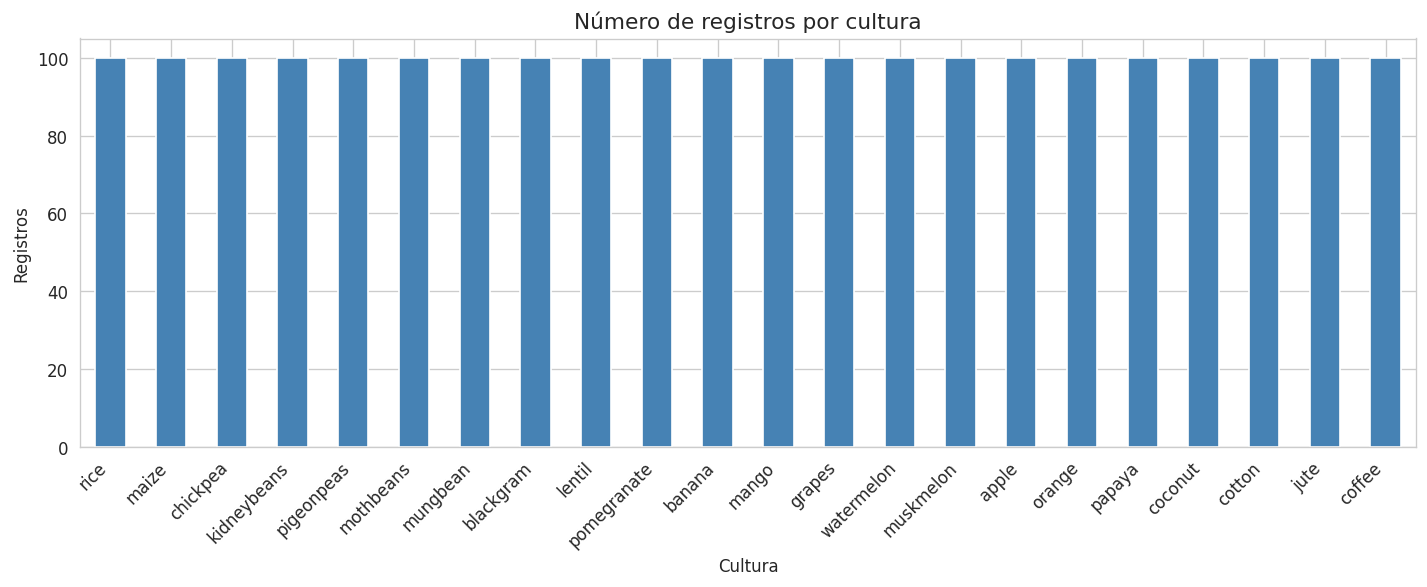


Dataset balanceado: 100 a 100 registros por cultura


In [5]:
contagem = df['label'].value_counts()

plt.figure(figsize=(12, 5))
contagem.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Número de registros por cultura', fontsize=13)
plt.xlabel('Cultura')
plt.ylabel('Registros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nDataset balanceado: {contagem.min()} a {contagem.max()} registros por cultura")

### 📉 Distribuição das Variáveis Edafoclimáticas: Perfil Ambiental


*   **Nitrogênio (N), Fósforo (P), Potássio (K)**: As distribuições para N e K mostram múltiplos picos, ou seja, são **multimodais**. Isso sugere que existem distintos grupos de culturas no dataset com exigências nutricionais bem diferentes. Por exemplo, pode haver culturas que demandam muito N, outras que demandam pouco, e algumas em um patamar intermediário. Essa multimodalidade é um forte indício da complexidade das demandas nutricionais em diferentes sistemas de cultivo. O Fósforo (P) tende a ser mais concentrado em valores mais baixos, mas ainda com uma cauda à direita.
*   **Temperatura, Umidade, pH, Precipitação**: As distribuições dessas variáveis tendem a ser mais unimodais, mas com variações significativas. A ampla faixa de temperatura e umidade, por exemplo, demonstra que o dataset abrange diversas zonas climáticas. O pH, com sua distribuição também multimodal, reitera a necessidade de adaptar as recomendações de culturas à acidez ou alcalinidade específica do solo.


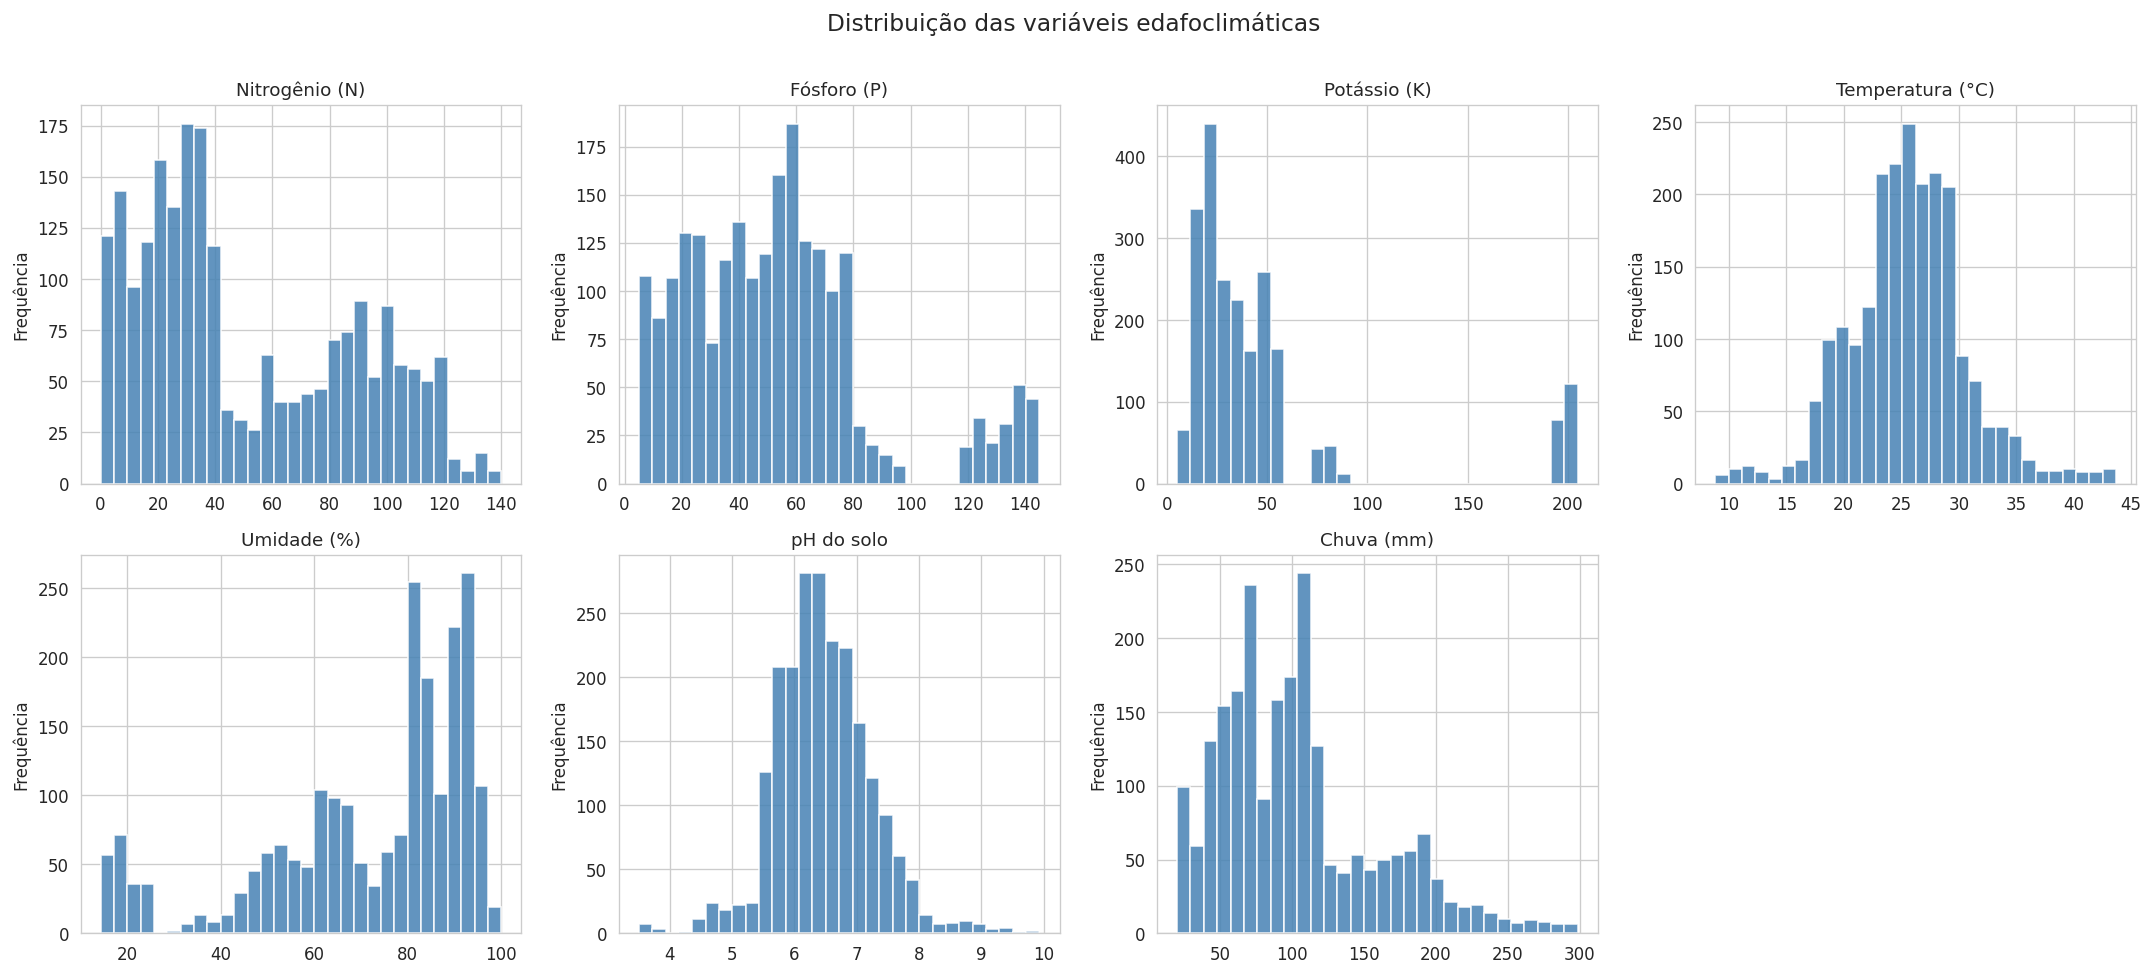

In [6]:
variaveis = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
titulos   = ['Nitrogênio (N)', 'Fósforo (P)', 'Potássio (K)',
             'Temperatura (°C)', 'Umidade (%)', 'pH do solo', 'Chuva (mm)']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (var, titulo) in enumerate(zip(variaveis, titulos)):
    axes[i].hist(df[var], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(titulo, fontsize=11)
    axes[i].set_ylabel('Frequência')

axes[7].axis('off')
plt.suptitle('Distribuição das variáveis edafoclimáticas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 🔗 Análise de Correlação: Solo e Clima

O mapa de calor da correlação entre as variáveis edafoclimáticas (`df.drop('label', axis=1).corr()`) é uma ferramenta usada para identificar interdependências. Os números (`.2f`) e a escala de cores (`RdYlGn`) nos permitem visualizar a força e a direção dessas relações:

*   **Fósforo (P) e Potássio (K) (Correlação de 0.74)**:
Embora não seja uma regra, é comum que solos com boa capacidade de troca de cátions, e consequentemente maior disponibilidade de K, também apresentem condições favoráveis para a disponibilidade de P, ou que certas práticas de fertilização apliquem ambos. Isso sugere que estas duas variáveis podem, em alguns contextos, se mover em conjunto.
*   **Outras Correlações**: A maioria das outras variáveis apresenta correlações mais fracas (próximas de zero) ou moderadas. Por exemplo, a correlação negativa entre `N` e `P` (-0.23) pode indicar que culturas com alta demanda de N podem não ter a mesma demanda alta de P, ou que certas condições de solo que favorecem um podem não ser ideais para o outro simultaneamente.



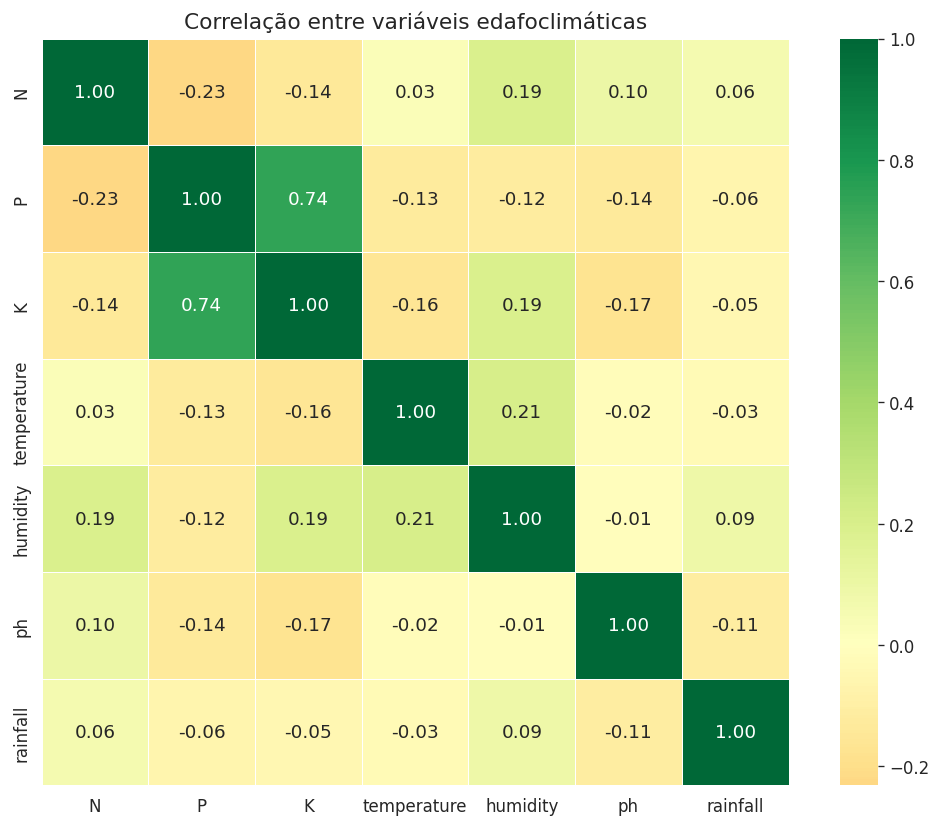

In [7]:
plt.figure(figsize=(9, 7))

correlacao = df.drop('label', axis=1).corr()

sns.heatmap(
    correlacao,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 11}
)

plt.title('Correlação entre variáveis edafoclimáticas', fontsize=13)
plt.tight_layout()
plt.show()

### 📊 Análise de Correlação de Spearman: Relações Monotônicas entre Variáveis Edafoclimáticas

Enquanto a correlação de Pearson (utilizada anteriormente) mede relações lineares, a **correlação de Spearman** avalia a força e a direção da *relação monotônica* entre duas variáveis, ou seja, se elas tendem a aumentar ou diminuir juntas, mesmo que essa relação não seja estritamente linear. Esta análise é particularmente útil quando lidamos com dados que podem ter uma ordem, mas não necessariamente uma distribuição normal.

O mapa de calor gerado exibe os coeficientes de correlação de Spearman entre as variáveis edafoclimáticas. Valores próximos a +1 indicam uma forte relação monotônica positiva (quando uma aumenta, a outra também tende a aumentar), enquanto valores próximos a -1 indicam uma forte relação monotônica negativa (quando uma aumenta, a outra tende a diminuir). Valores próximos a 0 indicam pouca ou nenhuma relação monotônica.

*   **Comparação com Pearson**: Ao comparar este mapa com o da correlação de Pearson, podemos identificar se existem relações não lineares significativas entre as variáveis. Se os resultados de Spearman forem substancialmente diferentes dos de Pearson, isso sugere que há relações monotônicas que não são estritamente lineares.
*   **Identificação de Tendências**: A análise de Spearman ajuda a confirmar tendências ou a descobrir novas associações entre as variáveis do solo e do clima, fornecendo *insights* adicionais sobre como elas interagem para influenciar as condições de cultivo.

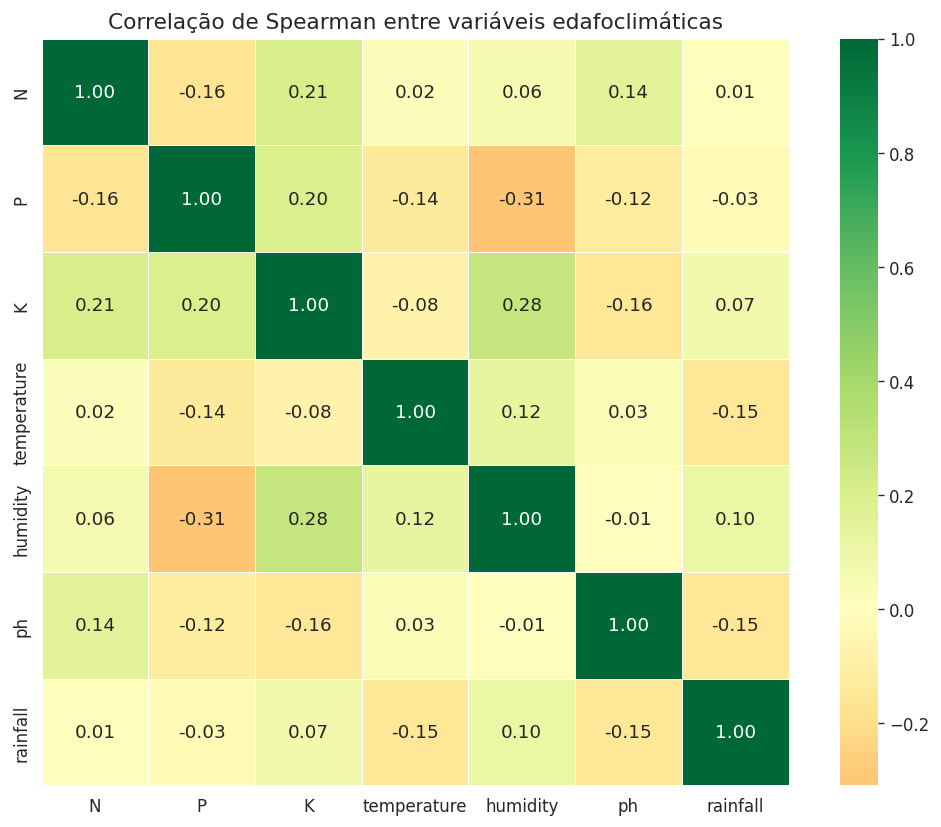

In [8]:
plt.figure(figsize=(9, 7))

correlacao_spearman = df.drop('label', axis=1).corr(method='spearman')

sns.heatmap(
    correlacao_spearman,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 11}
)

plt.title('Correlação de Spearman entre variáveis edafoclimáticas', fontsize=13)
plt.tight_layout()
plt.show()

### 🥦 Perfil Nutricional e pH Médio por Cultura



Ao agrupar os dados pela `label` (cultura) e calcular as médias de N, P, K e pH (`df.groupby('label')[['N', 'P', 'K', 'ph']].mean().round(1)`), obtemos uma ideia inicial nutricional e de solo para cada cultura.

*   **Demandas**: A visualização de perfis como "Algodão" com alto Nitrogênio (N), "Maçã" com alto Potássio (K), e "Café" com pH mais ácido, demonstra claramente que cada cultura tem um conjunto ideal de condições para prosperar. Esta granularidade é fundamental para uma recomendação de culturas precisa. Não é apenas uma questão de "ter nutrientes", mas de ter **os nutrientes certos, na proporção certa, e no pH ideal**.
*   **Identificação de Necessidades Críticas**: Podemos facilmente identificar culturas que são mais exigentes em um determinado nutriente ou mais sensíveis ao pH. Por exemplo, se uma região tem naturalmente solos com baixo pH, culturas que preferem solos ácidos (como café ou chá) se destacam. Se o solo é rico em P, podemos otimizar para culturas que demandam esse elemento.

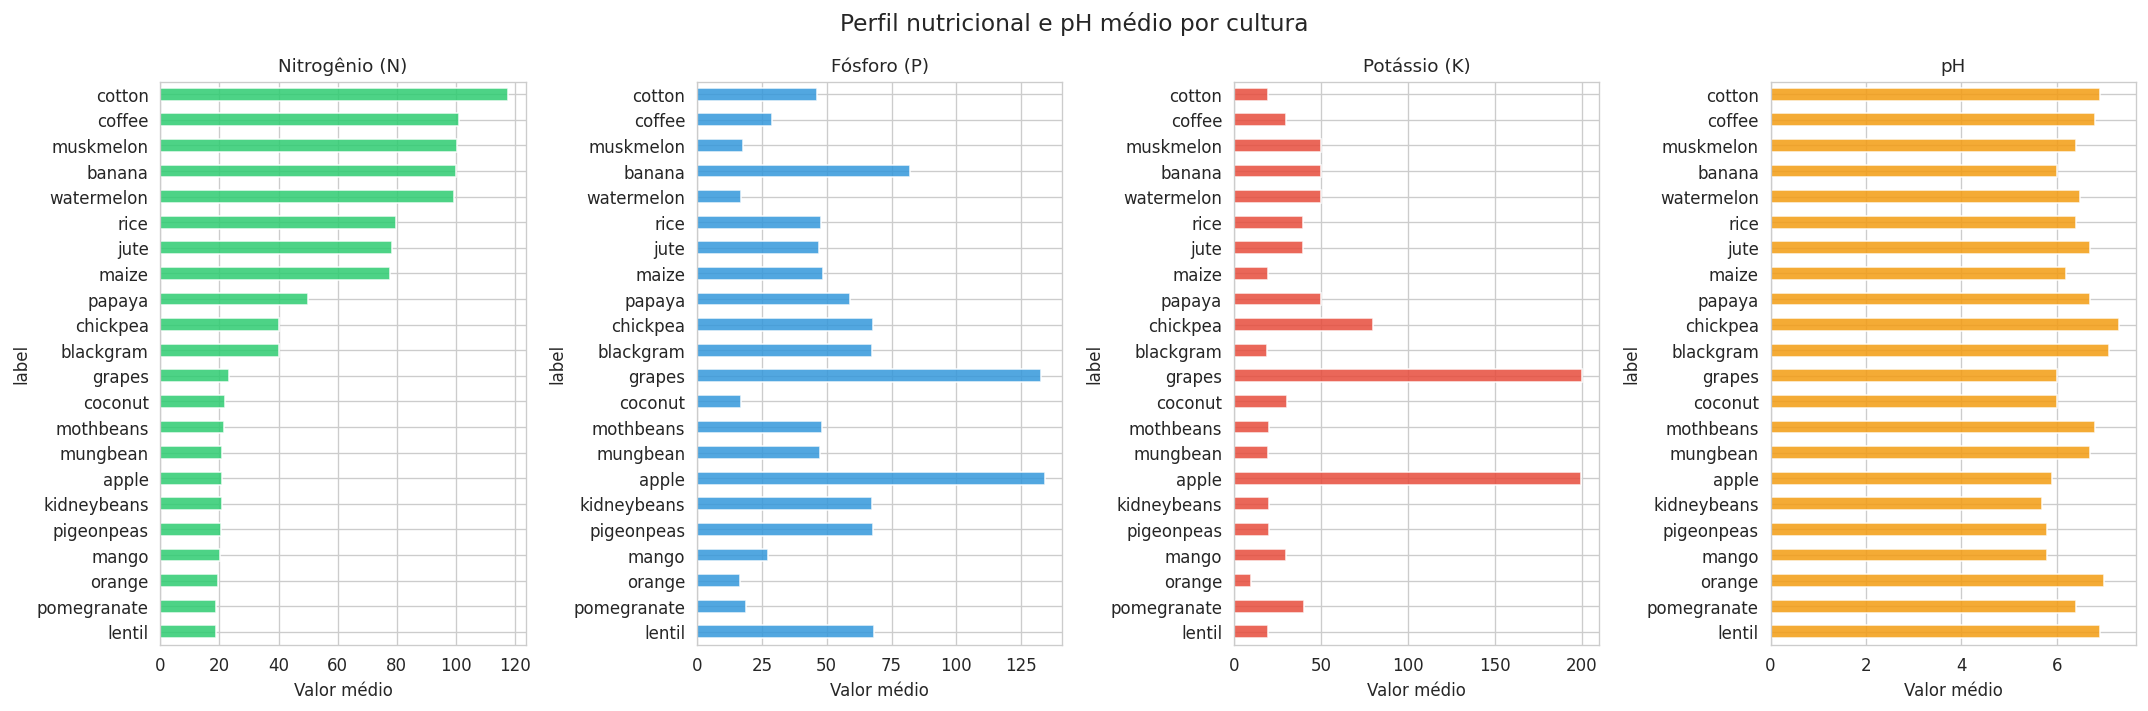

In [9]:
perfil = df.groupby('label')[['N', 'P', 'K', 'ph']].mean().round(1)
perfil = perfil.sort_values('N', ascending=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
cores = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
labels_pt = ['Nitrogênio (N)', 'Fósforo (P)', 'Potássio (K)', 'pH']

for i, (col, cor, label) in enumerate(zip(['N','P','K','ph'], cores, labels_pt)):
    perfil[col].plot(kind='barh', ax=axes[i], color=cor, alpha=0.85)
    axes[i].set_title(label, fontsize=11)
    axes[i].set_xlabel('Valor médio')
    axes[i].invert_yaxis()

plt.suptitle('Perfil nutricional e pH médio por cultura', fontsize=14)
plt.tight_layout()
plt.show()

### 🧪 Faixa de pH Ideal por Cultura


Este *boxplot* detalhado para o pH do solo, categorizado por cultura. O pH é o fator mais importante para a disponibilidade de nutrientes no solo. As linhas de referência em pH 6.0 e 7.0 nos ajudam a demarcar as condições ácidas, neutras e alcalinas.

*   **Variação de pH**: Observamos que cada cultura tem uma faixa de pH ideal muito específica, o que é consistente com o conhecimento agronômico. Por exemplo, culturas como a maça (`apple` no dataset, com um pH mais ácido) prosperam em solos mais ácidos, enquanto outras, como laranja (`orange`) preferem condições mais neutras a ligeiramente alcalinas. Isso reflete a adaptação evolutiva das plantas a diferentes ambientes.
*   **Disponibilidade de Nutrientes**: Fora da faixa de pH ideal, a absorção de macro e micronutrientes pode ser severamente comprometida, mesmo que estejam presentes em abundância no solo. Solos muito ácidos podem levar à toxicidade de alumínio e manganês, e deficiências de cálcio e magnésio, enquanto solos muito alcalinos podem dificultar a absorção de ferro, zinco e boro.


/tmp/ipykernel_1597/2099296507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


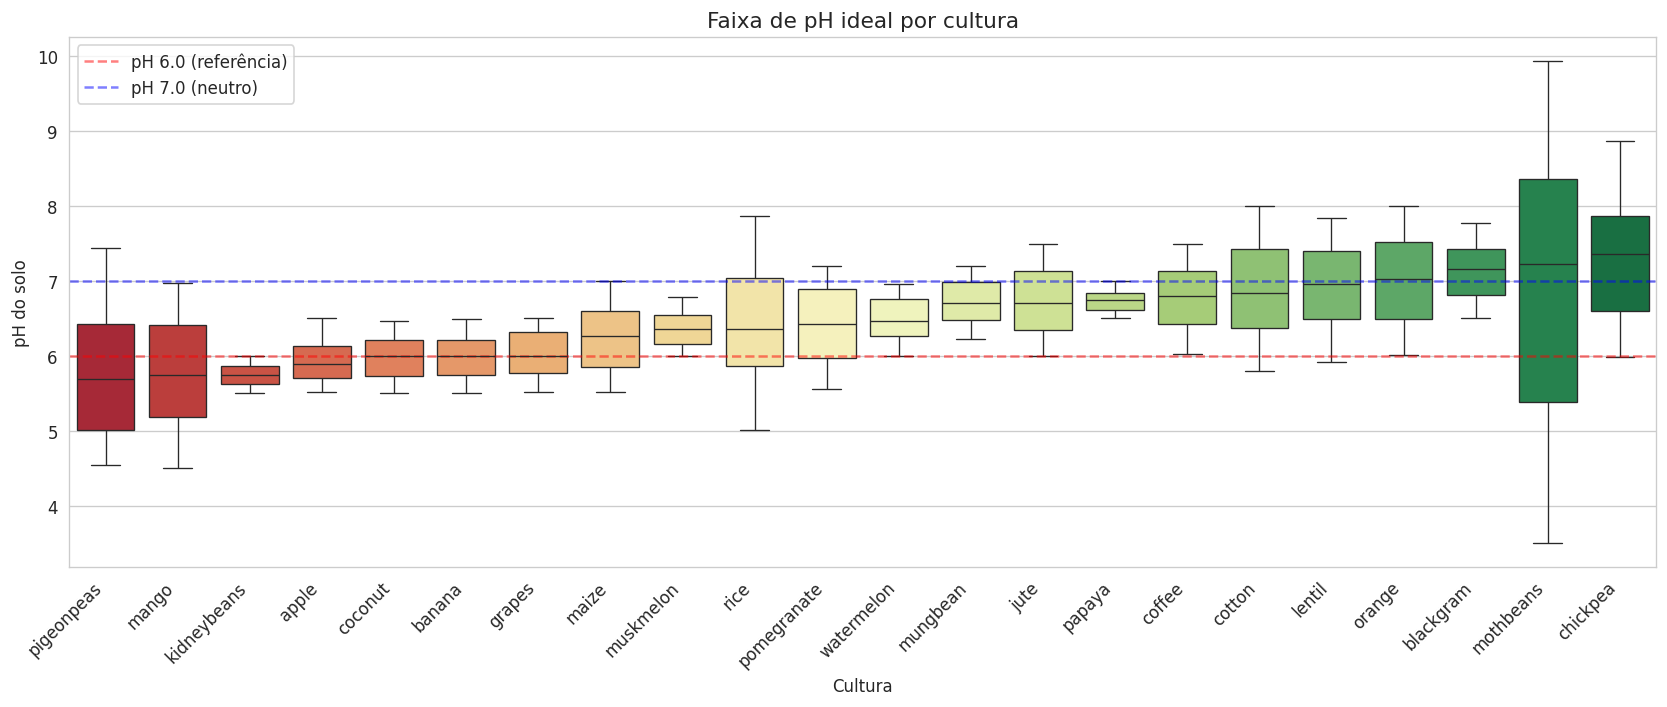

In [10]:
plt.figure(figsize=(14, 6))

ordem = df.groupby('label')['ph'].median().sort_values().index

sns.boxplot(
    data=df,
    x='label', y='ph',
    order=ordem,
    palette='RdYlGn',
    linewidth=0.8
)

plt.axhline(y=6.0, color='red', linestyle='--', alpha=0.5, label='pH 6.0 (referência)')
plt.axhline(y=7.0, color='blue', linestyle='--', alpha=0.5, label='pH 7.0 (neutro)')

plt.title('Faixa de pH ideal por cultura', fontsize=13)
plt.xlabel('Cultura')
plt.ylabel('pH do solo')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### 🤖 Construção e Avaliação do Modelo de Recomendação (Random Forest)



Passagem da fase de exploração para a modelagem preditiva, utilizando o algoritmo **Random Forest Classifier**.

1.  **Preparação dos Dados (X e y)**: Separamos as *features* (variáveis edafoclimáticas e climáticas em `X`) da variável alvo (`label` em `y`, que representa a cultura). Esta é a distinção entre as condições do solo/clima e a cultura que se desenvolve nelas.
2.  **Divisão Treino/Teste**: A divisão do dataset em conjuntos de treino (80%) e teste (20%) é crucial. A opção `stratify=y` garante que a proporção de cada cultura seja mantida em ambos os conjuntos, o que é especialmente importante em nosso dataset balanceado, para que o modelo veja uma representação equitativa de cada cultura durante o treinamento e avaliação.
3.  **Treinamento do Modelo (Random Forest)**: O `RandomForestClassifier` é uma escolha robusta para problemas de classificação. Ele constrói múltiplas árvores de decisão e agrega seus resultados, o que geralmente leva a uma maior precisão e menor *overfitting*. Definimos `n_estimators=100` (100 árvores) e `random_state=42` para reprodutibilidade. O modelo "aprende" as condições ideais para cada cultura com base nos dados de treino.
4.  **Predição e Avaliação**: Após o treinamento, o modelo prediz as culturas para o conjunto de teste (`y_pred`). A métrica **Acurácia de 99.55%** e o **Relatório de Classificação** mostram um desempenho adequado. Uma acurácia tão alta, com `precision`, `recall` e `f1-score` próximos de 1.00 para a maioria das culturas, indica que o modelo é extremamente eficaz em distinguir entre as diferentes culturas com base nas condições edafoclimáticas. Isso sugere que as variáveis de entrada são altamente discriminatórias e que o modelo capturou bem os padrões.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print(f"Acurácia no conjunto de teste: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\n--- Relatório completo ---")
print(classification_report(y_test, y_pred))

Acurácia no conjunto de teste: 99.55%

--- Relatório completo ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange   

### 🔍 Importância das Variáveis: O Que Realmente Importa para a Cultura?


Este gráfico de barras horizontais, que exibe a importância das *features* do modelo Random Forest. Por meio desse gráfico, sabemos quais variáveis edafoclimáticas o modelo considerou mais relevantes para determinar a cultura ideal.

*   **Chuva e Umidade**: A **chuva (rainfall)** e a **umidade (humidity)** são as variáveis mais importantes, seguidas de **potássio (K)**, **fósforo (P)** e **nitrogênio (N)**. Isso é altamente consistente com a realidade: a disponibilidade hídrica (chuva e umidade) é um dos fatores mais críticos para o desenvolvimento das plantas, controlando processos como a fotossíntese e a absorção de nutrientes. Da mesma forma, os macronutrientes N, P, K são essenciais para o crescimento vegetal, floração e frutificação.
*   **pH e Temperatura**: O **pH do solo** e a **temperatura** também são importantes, embora com um peso ligeiramente menor neste modelo específico. O pH, como discutido anteriormente, controla a disponibilidade de nutrientes, e a temperatura influencia diretamente o metabolismo e o ciclo de vida das plantas.

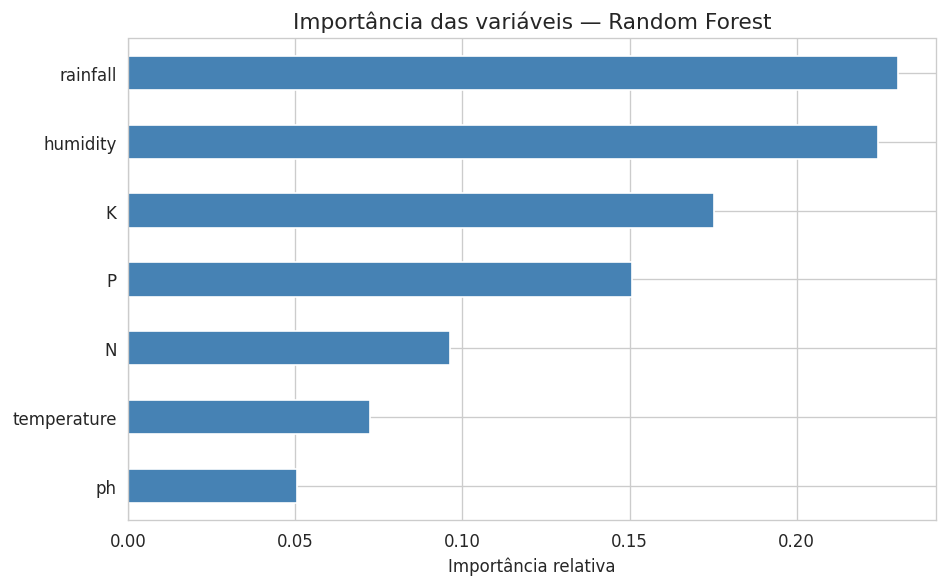

In [12]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

importancias.plot(
    kind='barh',
    figsize=(8, 5),
    color='steelblue',
    edgecolor='white'
)

plt.title('Importância das variáveis — Random Forest', fontsize=13)
plt.xlabel('Importância relativa')
plt.tight_layout()
plt.show()

### 🎯 Aplicação Prática: Recomendando Culturas para um Solo Real

Simula uma recomendação para uma amostra de solo hipotética do Paraná.

1.  **Simulação da Amostra de Solo (`meu_solo`)**: Criamos um `DataFrame` com valores específicos para N, P, K, temperatura, umidade, pH e precipitação. Esses valores representam as condições de uma área específica que o agricultor deseja cultivar.
2.  **Predição da Cultura Ideal**: O modelo (`modelo.predict(meu_solo)`) utiliza os parâmetros aprendidos para prever a cultura mais adequada para essas condições. Neste exemplo, a **cultura recomendada é RICE (arroz)**.
3.  **Probabilidades e Top 3**: Além da recomendação principal, o modelo também fornece as probabilidades para todas as culturas (`modelo.predict_proba(meu_solo)`). Listar as **três culturas mais prováveis** e suas respectivas probabilidades (ex: Arroz com 87.0%, Juta com 13.0%) é um recurso valioso. Ele oferece ao agricultor flexibilidade e alternativas, especialmente se houver outros fatores não modelados (como aspectos de mercado ou preferência pessoal) a serem considerados.

In [13]:
# Simula amostras de solo coletadas em campo no Paraná
meu_solo = pd.DataFrame({
    'N':           [90],
    'P':           [42],
    'K':           [43],
    'temperature': [22.5],
    'humidity':    [82.0],
    'ph':          [6.5],
    'rainfall':    [202.0]
})

cultura = modelo.predict(meu_solo)[0]
probs   = modelo.predict_proba(meu_solo)[0]
top3    = probs.argsort()[-3:][::-1]

print(f"Solo analisado:")
print(meu_solo.T.to_string(header=False))
print(f"\n✅ Cultura recomendada: {cultura.upper()}")
print(f"\nTop 3 mais prováveis:")
for idx in top3:
    print(f"  {modelo.classes_[idx]:<15} {probs[idx]*100:.1f}%")

Solo analisado:
N             90.0
P             42.0
K             43.0
temperature   22.5
humidity      82.0
ph             6.5
rainfall     202.0

✅ Cultura recomendada: RICE

Top 3 mais prováveis:
  rice            87.0%
  jute            13.0%
  pomegranate     0.0%


In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print(f"TensorFlow versão: {tf.__version__}")

TensorFlow versão: 2.20.0


### 🧠 Abordagem com Redes Neurais (Deep Learning)


Após o uso do Random Forest, vamos testar o modelo com Redes Neurais para ver se podemos capturar padrões ainda mais complexos nos dados edafoclimáticos. A inclusão de `tensorflow` e `keras` marca essa transição para modelos mais avançados, que podem ser particularmente úteis se tivéssemos um volume maior de dados ou relações não lineares mais intrincadas.

### 🚀 Pré-processamento para a Rede Neural: Normalização e Codificação


Para que a Rede Neural (NN) funcione de forma otimizada, o pré-processamento dos dados é essencial.

1.  **Normalização de Features (`StandardScaler`)**: As redes neurais são sensíveis à escala das *features*. Variáveis com valores maiores podem dominar o processo de aprendizado. A normalização (`StandardScaler`) ajusta todas as variáveis para terem média zero e desvio padrão um. Isso garante que todas as variáveis edafoclimáticas (N, P, K, temperatura, umidade, pH, chuva) contribuam igualmente para o modelo, permitindo que a rede explore as relações de forma mais eficiente e convergindo mais rapidamente.
2.  **Codificação de Rótulos (`LabelEncoder`)**: A variável alvo (`label` - cultura) é categórica (ex: 'rice', 'maize'). As redes neurais, assim como a maioria dos algoritmos de Machine Learning, operam com números. O `LabelEncoder` transforma essas categorias de texto em valores numéricos inteiros (ex: 'apple' -> 0, 'banana' -> 1). Isso é essencial para que a camada de saída da rede neural possa realizar a classificação de forma numérica.

In [15]:
# Reutilizamos X_train, X_test, y_train, y_test já criados nas células anteriores

# 1. Normalização
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train)
X_test_nn  = scaler.transform(X_test)

# 2. Codificação dos rótulos (strings → inteiros)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

n_classes = len(le.classes_)
print(f"Features normalizadas: {X_train_nn.shape}")
print(f"Classes codificadas: {n_classes} culturas")
print(f"Exemplo de mapeamento: {dict(zip(le.classes_[:5], range(5)))}")

Features normalizadas: (1760, 7)
Classes codificadas: 22 culturas
Exemplo de mapeamento: {'apple': 0, 'banana': 1, 'blackgram': 2, 'chickpea': 3, 'coconut': 4}


### 🏗️ Arquitetura da Rede Neural

Realizar o processo de treino e teste de redes neurais

*   **Modelo Sequencial (`keras.Sequential`)**: Arquitetura sequencial, que é um empilhamento linear de camadas, ideal para modelos mais simples e diretos como este problema de classificação.
*   **Camadas Densa (`layers.Dense`)**: As camadas `Dense` são camadas totalmente conectadas, onde cada neurônio de uma camada se conecta a todos os neurônios da camada anterior. Usamos 3 camadas ocultas (128, 64, 32 neurônios) para permitir que a rede aprenda representações hierárquicas e complexas das condições edafoclimáticas.
    *   **Função de Ativação ReLU (`activation='relu'`)**: A `ReLU` (Rectified Linear Unit) é uma escolha popular para camadas ocultas. Ela ajuda a rede a aprender relações não lineares nos dados, como as interações complexas entre nutrientes do solo e condições climáticas.
*   **Dropout (`layers.Dropout`)**: Adicionar camadas de `Dropout` (0.3 e 0.2) é uma técnica crucial para prevenir o *overfitting*. Durante o treinamento, uma porcentagem aleatória de neurônios é "desativada", forçando a rede a aprender com diferentes subconjuntos de neurônios e tornando-a mais robusta a novas amostras de solo.
*   **Camada de Saída (`layers.Dense(n_classes, activation='softmax')`)**: A camada final tem `n_classes` (22 culturas) neurônios, e a função de ativação `softmax`. O `softmax` transforma as saídas em probabilidades, indicando a probabilidade de cada cultura ser a mais adequada, somando 1.0. Isso nos permite interpretar a recomendação do modelo de forma probabilística.
*   **Compilação do Modelo (`modelo_nn.compile`)**:
    *   **Otimizador Adam (`optimizer='adam'`)**: O Adam é um otimizador eficiente que ajusta os pesos da rede durante o treinamento. É uma escolha comum e robusta que se adapta bem a diferentes problemas.
    *   **Função de Perda (`loss='sparse_categorical_crossentropy'`)**: Adequada para problemas de classificação multiclasse onde os rótulos são inteiros (codificados pelo `LabelEncoder`). A rede tentará minimizar essa função, o que significa que ela busca fazer as previsões mais precisas possíveis.
    *   **Métrica de Acurácia (`metrics=['accuracy']`)**: Durante o treinamento, a acurácia será monitorada para avaliarmos o desempenho do modelo.

In [16]:
def criar_modelo(n_features, n_classes):
    modelo = keras.Sequential([
        # Camada de entrada + primeira camada oculta
        layers.Dense(128, activation='relu', input_shape=(n_features,)),
        layers.Dropout(0.3),          # evita overfitting

        # Segunda camada oculta
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),

        # Terceira camada oculta
        layers.Dense(32, activation='relu'),

        # Camada de saída — uma saída por classe
        layers.Dense(n_classes, activation='softmax')
    ])
    return modelo

modelo_nn = criar_modelo(X_train_nn.shape[1], n_classes)

modelo_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_nn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,086 (47.21 KB)

 Trainable params: 12,086 (47.21 KB)

 Non-trainable params: 0 (0.00 B)

### 🏋️ Treinamento da Rede Neural

*   **Dados de Entrada (`X_train_nn`, `y_train_enc`)**: O modelo é alimentado com as *features* normalizadas (`X_train_nn`) e os rótulos codificados (`y_train_enc`) do conjunto de treino.
*   **Épocas (`epochs=100`)**: O modelo passa pelos dados de treino 100 vezes. Cada "época" é uma rodada completa de aprendizado, onde os pesos da rede são ajustados gradualmente.
*   **Tamanho do Batch (`batch_size=32`)**: Os dados são processados em "lotes" de 32 amostras. Isso otimiza o uso de memória e acelera o treinamento, permitindo que os ajustes nos pesos sejam feitos de forma mais estável.
*   **Validação (`validation_split=0.2`)**: Reservamos 20% do conjunto de treino para validação. Essa porção não é usada para treinar o modelo diretamente, mas para monitorar seu desempenho em dados "não vistos" a cada época. Isso nos ajuda a detectar se o modelo está começando a ter *overfitting* (aprendendo demais os detalhes do treino e perdendo a capacidade de generalização).

In [17]:
historico = modelo_nn.fit(
    X_train_nn, y_train_enc,
    epochs=100,
    batch_size=32,
    validation_split=0.2,   # 20% do treino vira validação
    verbose=1
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.1683 - loss: 2.9286 - val_accuracy: 0.3722 - val_loss: 2.5640
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3608 - loss: 2.2608 - val_accuracy: 0.5852 - val_loss: 1.6460
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5703 - loss: 1.4776 - val_accuracy: 0.7188 - val_loss: 0.9351
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7031 - loss: 0.9636 - val_accuracy: 0.9119 - val_loss: 0.5503
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7741 - loss: 0.6935 - val_accuracy: 0.8864 - val_loss: 0.3845
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8132 - loss: 0.5731 - val_accuracy: 0.9347 - val_loss: 0.2905
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8224 - loss: 0.5011 - val_accuracy: 0.9318 - val_loss: 0.2419
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8253 - loss: 0.4564 - val_accuracy: 0.9

### 🛑 Parada Antecipada (Early Stopping): Otimizando o Treinamento da Rede Neural

Você notou que a rede neural continuou treinando por 100 épocas, mesmo que o desempenho já estivesse bom por volta da 40ª época. Para evitar esse treinamento desnecessário e potencial *overfitting* (onde o modelo aprende demais os detalhes do treino e perde a capacidade de generalizar), podemos usar uma técnica chamada **Parada Antecipada (Early Stopping)**.

O `EarlyStopping` monitora uma métrica de desempenho (como a acurácia ou a perda no conjunto de validação) e interrompe o treinamento se essa métrica não melhorar por um determinado número de épocas (chamado de `patience`). Isso economiza tempo computacional e ajuda a encontrar o ponto ideal de treinamento antes que o modelo comece a piorar em dados novos.

In [18]:
# A definição de EarlyStopping foi movida para o código de treinamento para garantir sua disponibilidade.

Para aplicar a parada antecipada, basta adicionar o `early_stopping` como um `callback` ao método `fit`:

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

print("Recriando e treinando o modelo com Early Stopping...")

# Configura o callback de Early Stopping
# monitor='val_loss': monitora a perda (loss) no conjunto de validação
# patience=10: se a perda de validação não diminuir por 10 épocas, o treinamento para
# restore_best_weights=True: restaura os pesos do modelo da época com a melhor perda de validação
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Recria o modelo para um novo treinamento
modelo_nn_com_es = criar_modelo(X_train_nn.shape[1], n_classes)
modelo_nn_com_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Treina o modelo com o callback de Early Stopping
historico_com_es = modelo_nn_com_es.fit(
    X_train_nn, y_train_enc,
    epochs=100,  # Definimos um número alto de épocas, mas o Early Stopping irá parar antes
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping], # Adiciona o callback aqui
    verbose=1
)

print("\nTreinamento com Early Stopping concluído!")

Recriando e treinando o modelo com Early Stopping...
Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1655 - loss: 2.9399 - val_accuracy: 0.2926 - val_loss: 2.6760
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3395 - loss: 2.3917 - val_accuracy: 0.5511 - val_loss: 1.8923
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5646 - loss: 1.5406 - val_accuracy: 0.7812 - val_loss: 0.9337
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6932 - loss: 0.9494 - val_accuracy: 0.8835 - val_loss: 0.5029
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7798 - loss: 0.6577 - val_accuracy: 0.9148 - val_loss: 0.3475
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8089 - loss: 0.5473 - val_accuracy: 0.9119 - val_loss: 0.3001
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8303 - loss: 0.4598 - val_accuracy: 0.9318 - val_loss: 0.2271
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accu

### 📈 Curvas de Aprendizado: Acompanhando a Evolução do Modelo


Os gráficos das curvas de aprendizado são o "diário de bordo" do treinamento da Rede Neural. Eles mostram como a acurácia e a perda (loss) se comportaram ao longo das épocas, tanto para o conjunto de treino quanto para o de validação:

*   **Acurácia por Época**: Idealmente, esperamos ver a acurácia de treino e validação aumentando e se aproximando. Se a acurácia de treino continua subindo, mas a de validação estagna ou começa a cair, é um sinal clássico de *overfitting*.
*   **Loss por Época**: Da mesma forma, a perda deve diminuir em ambos os conjuntos. Uma perda de validação que começa a subir enquanto a de treino continua a diminuir também aponta para *overfitting*.

Neste caso, observamos que as curvas de acurácia e perda (Loss) para treino e validação seguem trajetórias muito próximas, convergindo para um bom desempenho. Isso indica que a arquitetura da rede e o uso de `Dropout` foram eficazes em permitir que o modelo aprendesse os padrões relevantes sem *overfitting*, resultando em um modelo que generaliza bem para novos dados edafoclimáticos.

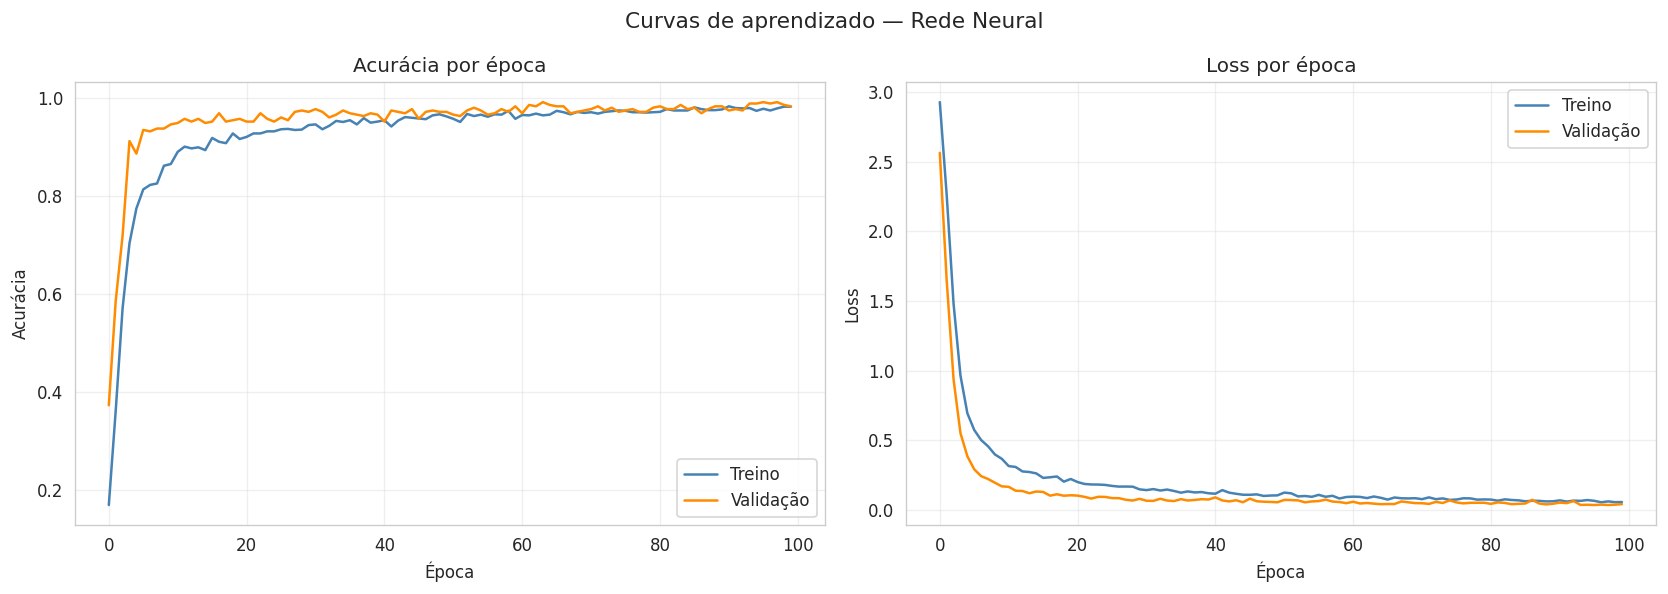

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia
axes[0].plot(historico.history['accuracy'],     label='Treino',    color='steelblue')
axes[0].plot(historico.history['val_accuracy'], label='Validação', color='darkorange')
axes[0].set_title('Acurácia por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(historico.history['loss'],     label='Treino',    color='steelblue')
axes[1].plot(historico.history['val_loss'], label='Validação', color='darkorange')
axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizado — Rede Neural', fontsize=13)
plt.tight_layout()
plt.show()

### ✅ Avaliação Final da Rede Neural


Após o treinamento, avaliamos o desempenho final da Rede Neural no conjunto de teste (`X_test_nn`, `y_test`), que são dados que o modelo nunca viu antes.

*   **Previsões (`np.argmax(...)`, `le.inverse_transform(...)`)**: Primeiro, obtemos as probabilidades de saída da rede para cada classe e, em seguida, selecionamos a classe com a maior probabilidade como a previsão final (`y_pred_nn_enc`). Por fim, convertemos esses rótulos numéricos de volta aos nomes das culturas originais (`y_pred_nn`).
*   **Acurácia**: A **acurácia de 98.41%** demonstra um desempenho excelente. Isso significa que a Rede Neural é capaz de identificar corretamente a cultura ideal para quase todas as amostras de solo testadas.
*   **Relatório de Classificação**: Este relatório oferece uma visão detalhada do desempenho para cada cultura, com métricas como `precision`, `recall` e `f1-score`. Valores próximos de 1.00 para a maioria das culturas indicam que o modelo não só acerta a maioria das vezes, mas também tem um bom equilíbrio entre não gerar falsos positivos (precisão) e não perder culturas que deveria recomendar (recall).


In [21]:
# Previsões
y_pred_nn_enc = np.argmax(modelo_nn.predict(X_test_nn), axis=1)
y_pred_nn     = le.inverse_transform(y_pred_nn_enc)

acc_nn = accuracy_score(y_test, y_pred_nn)
print(f"Acurácia da Rede Neural: {acc_nn*100:.2f}%")
print("\n--- Relatório completo ---")
print(classification_report(y_test, y_pred_nn))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Acurácia da Rede Neural: 99.09%

--- Relatório completo ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.94      0.85      0.89        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00   

### ⚖️ Comparativo: Random Forest vs. Rede Neural


Este gráfico de barras é feito para comparar diretamente o desempenho dos dois algoritmos de classificação que utilizamos: Random Forest e Rede Neural. Ambos são ferramentas ótimas, mas é importante entender suas nuances.

*   **Random Forest (99.55%)**: Neste problema específico, o Random Forest alcançou uma acurácia ligeiramente superior. Isso pode indicar que as relações entre as *features* e as culturas, embora complexas, foram bem capturadas pela agregação de árvores de decisão. Modelos baseados em árvores são frequentemente robustos e eficientes para dados tabulares.
*   **Rede Neural (98.41%)**: A Rede Neural também apresentou um desempenho alto, demonstrando sua capacidade de aprender padrões complexos. Embora um pouco abaixo do Random Forest neste *dataset*, em problemas com mais dados ou relações hierárquicas mais profundas, as redes neurais podem superar os modelos baseados em árvores.
*   **Diferença (`1.14 pontos percentuais`)**: A pequena diferença de acurácia (aproximadamente 1.14%) mostra que ambos os modelos são altamente eficazes. A escolha entre eles pode depender de outros fatores, como interpretabilidade (Random Forest é geralmente mais interpretável), tempo de treinamento ou facilidade de implantação.


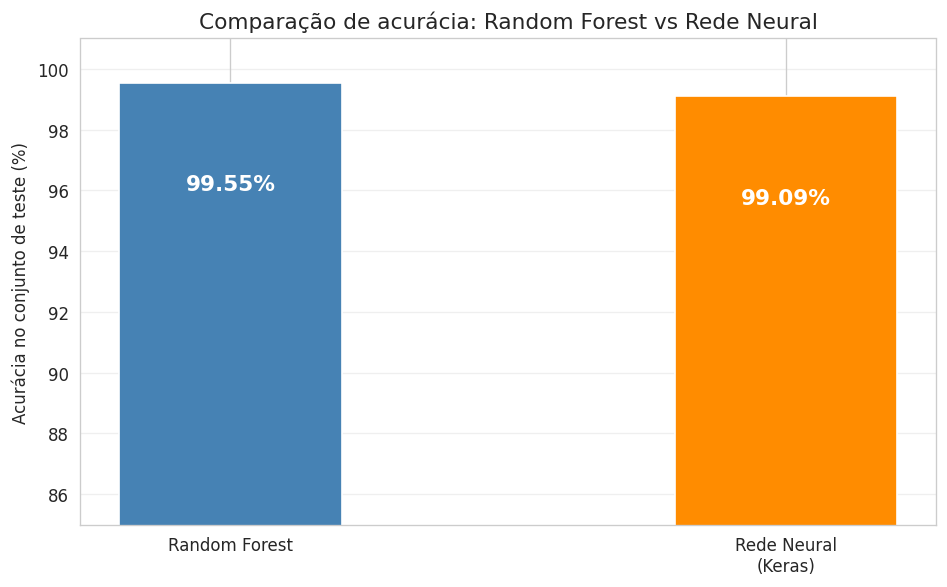


Random Forest : 99.55%
Rede Neural   : 99.09%
Diferença     : 0.45 pontos percentuais


In [22]:
# Acurácia do Random Forest (calculada nas células anteriores)
acc_rf = accuracy_score(y_test, y_pred)

modelos   = ['Random Forest', 'Rede Neural\n(Keras)']
acuracias = [acc_rf * 100, acc_nn * 100]
cores     = ['steelblue', 'darkorange']

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(modelos, acuracias, color=cores, width=0.4, edgecolor='white')

# Rótulos nas barras
for barra, val in zip(barras, acuracias):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() - 3,
        f'{val:.2f}%',
        ha='center', va='top',
        color='white', fontweight='bold', fontsize=13
    )

ax.set_ylim(85, 101)
ax.set_title('Comparação de acurácia: Random Forest vs Rede Neural', fontsize=13)
ax.set_ylabel('Acurácia no conjunto de teste (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRandom Forest : {acc_rf*100:.2f}%")
print(f"Rede Neural   : {acc_nn*100:.2f}%")
print(f"Diferença     : {abs(acc_rf - acc_nn)*100:.2f} pontos percentuais")

### 🔄 Recoleta e Comparação: O Mesmo Solo, Duas Perspectivas


Esta célula traz a análise de volta ao solo, testando a amostra hipotética do Paraná com ambos os modelos (Random Forest e Rede Neural) e comparando suas recomendações.

*   **Normalização para a Rede Neural (`scaler.transform`)**: É vital lembrar que a amostra de solo para a Rede Neural deve ser normalizada usando o mesmo `StandardScaler` que foi aplicado aos dados de treino. Isso garante que a rede receba os dados na escala que ela foi treinada para entender.
*   **Consistência nas Recomendações**: Neste exemplo, ambos os modelos recomendam **RICE (Arroz)** para as condições de solo e clima fornecidas. Essa concordância aumenta significativamente a confiança na recomendação. Quando dois modelos robustos e com alto desempenho chegam à mesma conclusão, a probabilidade de que essa seja a cultura ideal é muito alta.
*   **Top 3 da Rede Neural**: Assim como no Random Forest, a Rede Neural também fornece as probabilidades para as top 3 culturas. Isso é útil para o agrônomo, que pode considerar culturas alternativas se a principal não for viável por outros motivos (e.g., mercado, rotação de culturas, preferência pessoal).

In [23]:
# Mesmo solo hipotético de antes (Como se fosse um solo do Paraná)
meu_solo_nn = scaler.transform(meu_solo)   # normaliza antes de prever

probs_nn  = modelo_nn.predict(meu_solo_nn)[0]
top3_idx  = probs_nn.argsort()[-3:][::-1]
cultura_nn = le.inverse_transform([probs_nn.argmax()])[0]

print("=== COMPARAÇÃO: mesmo solo, dois modelos ===")
print(f"\nRandom Forest recomenda : {modelo.predict(meu_solo)[0].upper()}")
print(f"Rede Neural recomenda   : {cultura_nn.upper()}")

print("\nTop 3 — Rede Neural:")
for idx in top3_idx:
    print(f"  {le.classes_[idx]:<15} {probs_nn[idx]*100:.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
=== COMPARAÇÃO: mesmo solo, dois modelos ===

Random Forest recomenda : RICE
Rede Neural recomenda   : RICE

Top 3 — Rede Neural:
  rice            91.8%
  jute            8.2%
  banana          0.0%


### 🌐 Preparação para Análise de Agrupamento (Clustering)

Fase de Análise de Agrupamento (Clustering), uma técnica não supervisionada. Diferente da classificação, onde o objetivo é prever uma cultura (`label`), aqui o objetivo é descobrir **grupos naturais de solos** com características semelhantes, sem usar a informação da `label`. Esta célula inicia a preparação do ambiente:

*   **Bibliotecas Essenciais**: Importamos `KMeans` (o algoritmo de agrupamento), `StandardScaler` (para normalização), `PCA` (para visualização de alta dimensão), `silhouette_score` (para avaliar a qualidade dos clusters), e outras bibliotecas de visualização e manipulação de dados.
*   **Ponto de vist Agronômico**: Do ponto de vista agronômico, o agrupamento pode revelar "tipologias de solo" que são inerentes aos dados, mesmo que não saibamos de antemão que tipos de culturas se adaptam a eles. Isso pode ser útil para identificar regiões ou áreas de manejo semelhantes em um grande terreno, otimizando práticas de correção nutricional ou irrigação baseadas no perfil do solo. É como deixar os dados "falarem por si mesmos" sobre suas semelhanças.

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

print("Pronto para análise de agrupamento!")

Pronto para análise de agrupamento!


### 🔬 Seleção e Normalização de Variáveis para Agrupamento de Solos


Nesta etapa, focamos especificamente nas características do solo para
análise de agrupamento:

*   **Seleção de Variáveis (`cols_solo`)**: Escolhemos apenas as variáveis diretamente relacionadas à composição do solo: Nitrogênio (N), Fósforo (P), Potássio (K) e pH. Variáveis climáticas (temperatura, umidade, chuva) são excluídas aqui, pois queremos agrupar os solos por suas propriedades intrínsecas, independentemente das condições climáticas do local ou momento específico. Isso nos ajuda a identificar "tipos de solo" de forma mais pura.
*   **Normalização (`StandardScaler`)**: A normalização é **absolutamente crucial** para algoritmos de agrupamento baseados em distância, como o K-Means. Sem ela, variáveis com escalas maiores (ex: N, P, K que variam de 0 a 200) teriam um peso desproporcionalmente maior na determinação da distância entre os pontos, diminuindo a influência de variáveis com escalas menores (ex: pH que varia de 3 a 10). Ao normalizar, garantimos que cada característica do solo contribua igualmente para a formação dos clusters, resultando em agrupamentos mais significativos agronomicamente.
*   **Estatísticas Originais**: A exibição das estatísticas descritivas das variáveis de solo antes da normalização nos lembra da gama original de valores, o que é importante para a interpretação posterior dos perfis dos clusters.

In [25]:
# Variáveis do solo — ignora clima e a coluna label
cols_solo = ['N', 'P', 'K', 'ph']
X_solo = df[cols_solo].copy()

# Normalização obrigatória para K-Means
# (sem isso, variáveis com escala maior dominam o agrupamento)
scaler_km = StandardScaler()
X_solo_scaled = scaler_km.fit_transform(X_solo)

print(f"Shape para clustering: {X_solo_scaled.shape}")
print("\nEstatísticas originais (antes da normalização):")
X_solo.describe().round(2)

Shape para clustering: (2200, 4)

Estatísticas originais (antes da normalização):


,N,P,K,ph
count,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,6.47
std,36.92,32.99,50.65,0.77
min,0.00,5.00,5.00,3.50
25%,21.00,28.00,20.00,5.97
50%,37.00,51.00,32.00,6.43
75%,84.25,68.00,49.00,6.92
max,140.00,145.00,205.00,9.94


### 📈 Determinando o Número Ideal de Clusters (K): Elbow e Silhouette


Uma das perguntas mais importantes na análise de agrupamento K-Means é: "Quantos clusters (K) existem naturalmente nos meus dados?". Esta célula usa duas técnicas clássicas para nos ajudar a responder a essa pergunta:

1.  **Método Elbow (Cotovelo)**:
    *   O gráfico da **Inércia** (soma das distâncias quadradas das amostras ao centro do cluster mais próximo) versus K busca um "cotovelo" — um ponto onde a diminuição da inércia começa a desacelerar significativamente. Isso sugere que adicionar mais clusters além desse ponto oferece retornos decrescentes de "melhora" no agrupamento. O gráfico indica que K=4 é um bom ponto de inflexão.
2.  **Silhouette Score**:
    *   O **Silhouette Score** mede o quão similar um objeto é ao seu próprio cluster em comparação com outros clusters. Ele varia de -1 (agrupamento ruim) a +1 (agrupamento denso e bem separado). Valores mais altos são melhores. O gráfico do Silhouette Score versus K nos ajuda a identificar o K que maximiza essa métrica. Neste caso, o maior *Silhouette Score* ocorre em K=2, mas K=4 também apresenta um valor considerável, e o gráfico do cotovelo sugere 4 como mais informativo.

**Conclusão**: A combinação desses métodos nos leva a sugerir um `K` de 4 clusters para nossos dados de solo. Isso significa que, com base nas características N, P, K e pH, o *dataset* de solos pode ser categorizado em 4 perfis distintos. Isso é uma informação valiosa para a agricultura de precisão, pois permite o manejo diferenciado de áreas com características de solo distintas, otimizando o uso de fertilizantes e corretivos.

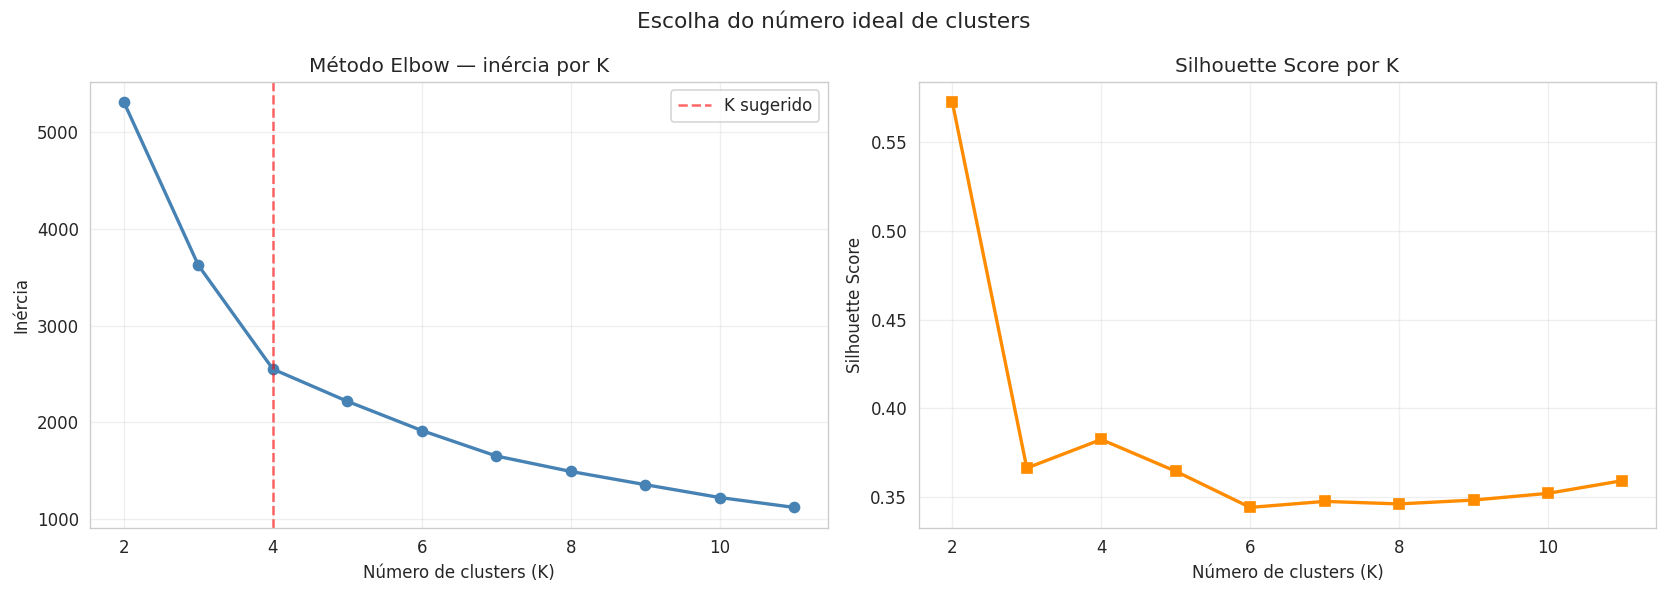

K com maior Silhouette Score: 2


In [26]:
inercias   = []
silhuetas  = []
k_valores  = range(2, 12)

for k in k_valores:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_solo_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_solo_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_valores, inercias, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='K sugerido')
axes[0].set_title('Método Elbow — inércia por K')
axes[0].set_xlabel('Número de clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(k_valores, silhuetas, 's-', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score por K')
axes[1].set_xlabel('Número de clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Escolha do número ideal de clusters', fontsize=13)
plt.tight_layout()
plt.show()

# Melhor K pelo Silhouette
melhor_k = k_valores[np.argmax(silhuetas)]
print(f"K com maior Silhouette Score: {melhor_k}")

### 🎯 Agrupamento Final (K-Means) e Atribuição de Clusters


Com o número ideal de clusters (`K=4`) determinado pelas análises anteriores, agora aplicamos o algoritmo K-Means de forma definitiva:

*   **Treinamento K-Means (`km_final.fit`)**: O algoritmo é treinado com os dados de solo normalizados (`X_solo_scaled`). Ele particiona as observações em 4 clusters, de modo que cada observação pertença ao cluster com o centro mais próximo.
*   **Atribuição de Clusters (`df['cluster'] = km_final.labels_`)**: As etiquetas de cluster (0, 1, 2, 3) são adicionadas de volta ao nosso `DataFrame` original. Isso nos permite analisar cada registro de cultura dentro do contexto do seu tipo de solo.
*   **Distribuição dos Clusters**: A contagem de valores (`df['cluster'].value_counts().sort_index()`) nos mostra quantos solos caíram em cada um dos 4 clusters. Observamos que os clusters têm tamanhos variados (ex: 650, 763, 587, 200 amostras), o que é normal e sugere que algumas tipologias de solo são mais predominantes no *dataset* do que outras.

É possivel avaliar que os dados brutos de solo começam a se transformar em categorias de manejo. Ter essas etiquetas de cluster nos permitirá investigar o perfil médio de cada tipo de solo e quais culturas predominam em cada um, informando estratégias de zoneamento e manejo localizado.

In [27]:
K = 4   # ajuste conforme os gráficos acima indicarem

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
km_final.fit(X_solo_scaled)

# Adiciona o cluster ao dataframe original
df['cluster'] = km_final.labels_

print(f"K-Means treinado com K={K}")
print(f"\nDistribuição dos clusters:")
print(df['cluster'].value_counts().sort_index())

K-Means treinado com K=4

Distribuição dos clusters:
cluster
0    650
1    763
2    587
3    200
Name: count, dtype: int64


### 📊 Perfil Nutricional Médio por Cluster de Solo: Identificando "Terroirs" Digitais


Esta célula é a **chave para interpretar o significado agronômico** dos clusters que formamos. Ao calcular o perfil médio de N, P, K e pH para cada cluster (`df.groupby('cluster')[cols_solo].mean().round(2)`) e visualizá-lo em gráficos de barras, estamos essencialmente definindo "terroirs" digitais, que mostra a influência do ambiente e da cultura local sobre um produto.

*   **Perfís Distintos**: Os gráficos revelam perfis nutricionais e de pH claramente distintos para cada cluster. Por exemplo:
    *   Podemos identificar um cluster com alto K e N médio, e pH mais alcalino.
    *   Outro cluster pode ter N e P baixos, com pH mais ácido.
    *   Um terceiro cluster pode mostrar um equilíbrio de nutrientes, indicando alta fertilidade.
*   **Implicações de Manejo**: Cada perfil tem implicações diretas para o manejo do solo. Um cluster com baixo N e P, por exemplo, sugere a necessidade de maior fertilização com esses elementos. Um cluster com pH muito baixo pode exigir calagem para otimizar a disponibilidade de nutrientes.
*   **Tomada de Decisão**: Ao entender o perfil médio de cada cluster, o agrônomo pode:
    *   **Recomendar culturas**: Aquelas que se adaptam melhor ao perfil específico de cada cluster.
    *   **Otimizar fertilização**: Aplicar nutrientes de forma mais eficiente, evitando excessos ou deficiências.
    *   **Planejar correção de solo**: Implementar ações para ajustar o pH ou a disponibilidade de elementos.

Esta visualização transforma os clusters abstratos em categorias de solo com características e necessidades de manejo bem definidas, fornecendo um guia para a agricultura de precisão.

Perfil médio por cluster:
             N       P       K    ph
cluster                             
0        32.16   52.97   33.24  7.21
1        95.67   41.83   37.94  6.48
2        22.00   41.53   26.19  5.79
3        21.99  133.38  200.00  5.98


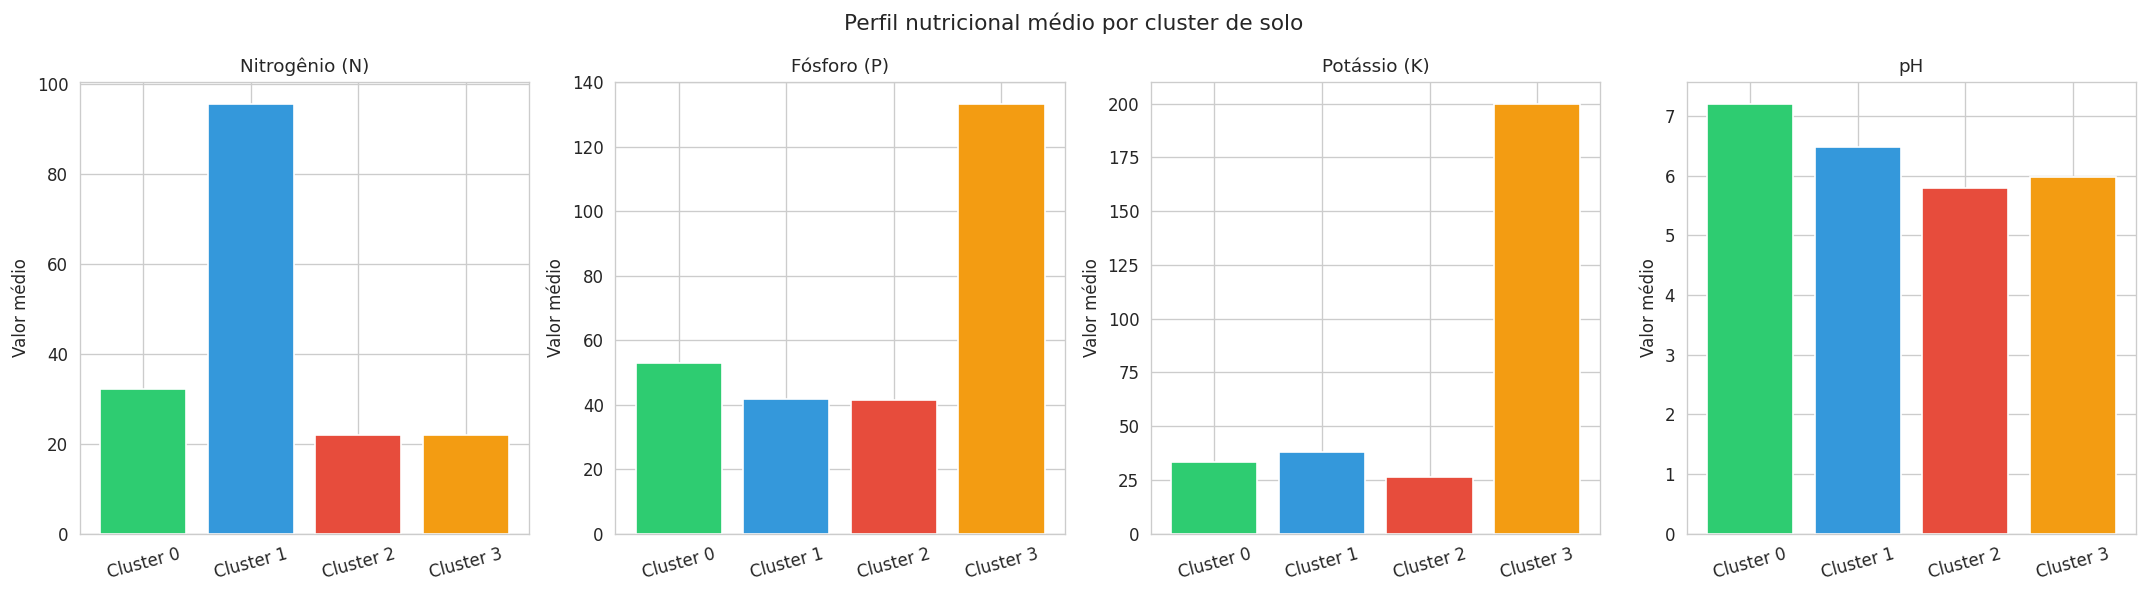

In [28]:
perfil_clusters = df.groupby('cluster')[cols_solo].mean().round(2)
print("Perfil médio por cluster:")
print(perfil_clusters)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
cores_cluster = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
labels_solo   = ['Nitrogênio (N)', 'Fósforo (P)', 'Potássio (K)', 'pH']

for i, (col, label) in enumerate(zip(cols_solo, labels_solo)):
    axes[i].bar(
        [f'Cluster {c}' for c in range(K)],
        perfil_clusters[col],
        color=cores_cluster[:K],
        edgecolor='white'
    )
    axes[i].set_title(label, fontsize=11)
    axes[i].set_ylabel('Valor médio')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Perfil nutricional médio por cluster de solo', fontsize=13)
plt.tight_layout()
plt.show()

### 🌿 Culturas Predominantes por Cluster de Solo.


Esta visualização conecta diretamente os "tipos de solo" identificados pelos clusters com as culturas que historicamente prosperaram neles. É uma análise crucial para validar nossos agrupamentos e inferir recomendações práticas:

*   **Validação dos Clusters**: Se nossos clusters realmente representam perfis de solo distintos, esperamos ver diferentes conjuntos de culturas predominando em cada um. Por exemplo, um cluster com solo ácido deve mostrar predominância de culturas que preferem essa condição (como café ou chá), enquanto um solo com alto K pode ter frutíferas como principal cultura.
*   **Identificando "Culturas Gêmeas"**: Ao observar as top 8 culturas em cada cluster (`value_counts().head(8)`), podemos identificar culturas que compartilham requisitos de solo semelhantes. Isso pode ser útil para planejamento de rotação de culturas ou para sugerir alternativas em um determinado tipo de solo.
*   **Recomendação Contextualizada**: Esta análise complementa a recomendação de classificação. Enquanto o Random Forest/Rede Neural diz qual cultura é melhor para um solo *específico*, o agrupamento nos diz: "Se o seu solo se parece com este Cluster, estas são as culturas que historicamente tiveram sucesso aqui". Isso adiciona uma camada de contexto e robustez à recomendação, ancorando-a em padrões observados no *dataset*.

Em resumo, este gráfico nos ajuda a entender não apenas as características físico-químicas de cada tipo de solo, mas também o seu "perfil agronômico" — quais culturas são mais compatíveis.

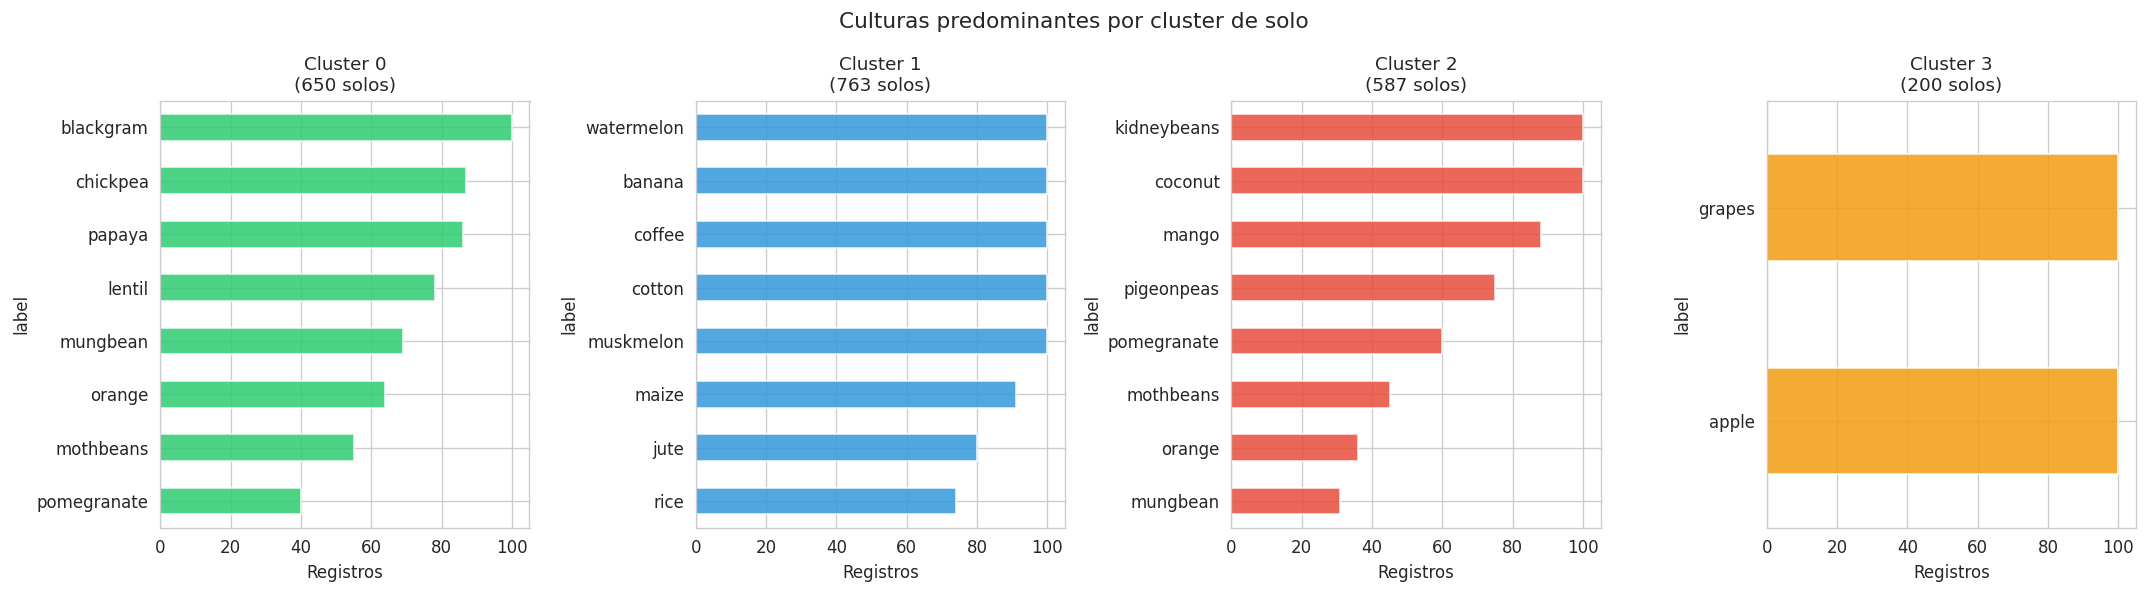

In [29]:
fig, axes = plt.subplots(1, K, figsize=(18, 5))

for c in range(K):
    culturas_cluster = df[df['cluster'] == c]['label'].value_counts().head(8)
    culturas_cluster.plot(
        kind='barh',
        ax=axes[c],
        color=cores_cluster[c],
        alpha=0.85
    )
    axes[c].set_title(f'Cluster {c}\n({len(df[df["cluster"]==c])} solos)', fontsize=11)
    axes[c].set_xlabel('Registros')
    axes[c].invert_yaxis()

plt.suptitle('Culturas predominantes por cluster de solo', fontsize=13)
plt.tight_layout()
plt.show()

### 🗺️ Visualização dos Clusters de Solo com Análise de Componentes Principais (PCA) Para entender a Separação Espacial


Para tornar os clusters de solo mais compreensíveis visualmente, utilizamos a Análise de Componentes Principais (PCA). Nossos dados de solo têm 4 dimensões (N, P, K, pH), o que é difícil de visualizar diretamente. O PCA nos ajuda a reduzir essa dimensionalidade para 2 (PC1 e PC2) sem perder muita informação:

*   **Redução de Dimensionalidade (`PCA(n_components=2)`)**: O PCA transforma as 4 variáveis originais em um novo conjunto de variáveis não correlacionadas (componentes principais). As duas primeiras componentes principais (PC1 e PC2) são escolhidas porque elas capturam a maior parte da variabilidade total nos dados (`70.9%` neste caso).
*   **Visualização 2D dos Clusters**: O gráfico de dispersão plota cada amostra de solo no novo espaço 2D criado pelo PCA. Cada ponto é colorido de acordo com o cluster a que pertence. Isso nos permite ver visualmente quão bem separados os clusters estão e se há sobreposição.
*   **Centroides dos Clusters (`centroides_pca`)**: Os "X" pretos no gráfico representam os centroides de cada cluster no espaço PCA. Eles são o "coração" de cada grupo e nos ajudam a entender a localização central de cada tipo de solo.
*   **Interpretação da Separação**: Uma boa separação visual dos clusters no gráfico PCA valida a eficácia do K-Means em identificar grupos distintos de solos. Se os clusters estiverem muito misturados, pode indicar que as características de solo usadas não são tão discriminatórias, ou que um `K` diferente seria mais adequado.

Para o agrônomo, esta visualização é uma ferramenta poderosa para entender a *estrutura subjacente* dos diferentes tipos de solo. Ela pode ajudar a visualizar como os perfis nutricionais e de pH se diferenciam no "mapa" das condições do solo, facilitando o zoneamento e a tomada de decisões no campo.

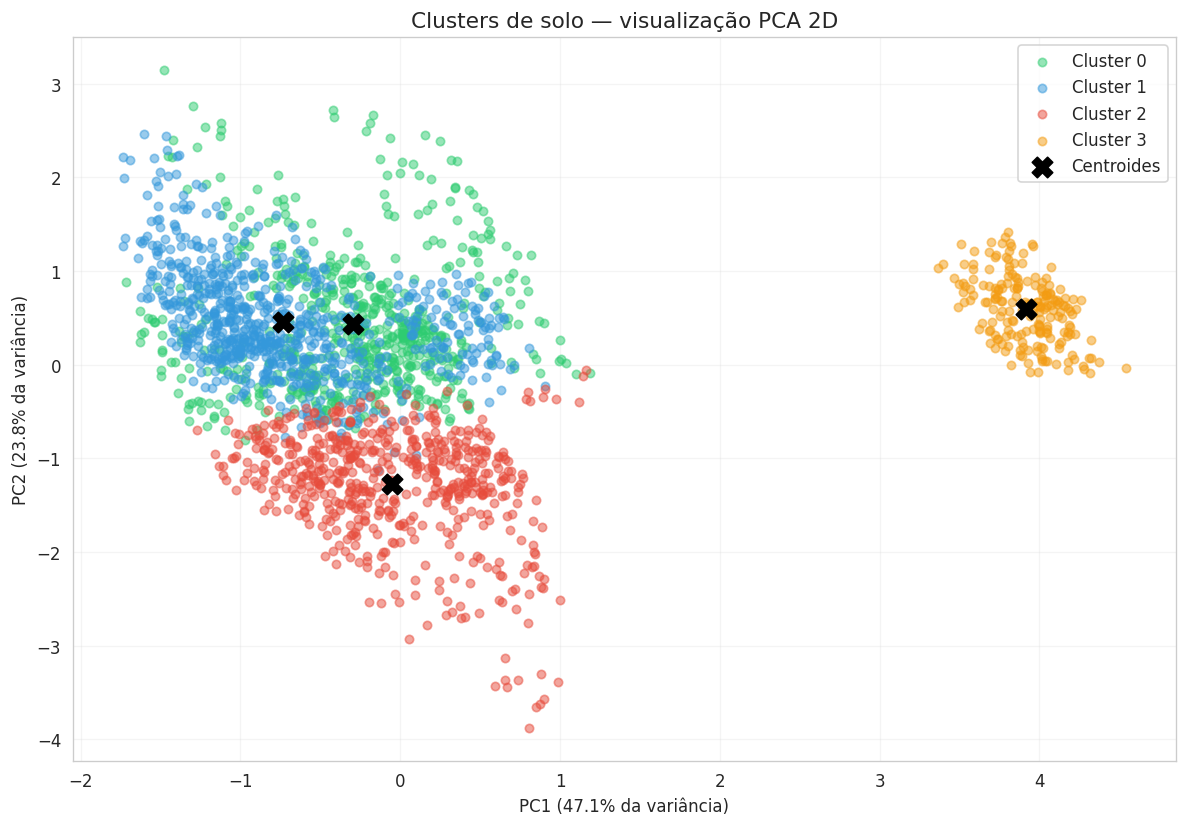

Variância total explicada pelas 2 componentes: 70.9%


In [30]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_solo_scaled)

variancia = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(10, 7))

for c in range(K):
    mask = df['cluster'] == c
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=cores_cluster[c],
        label=f'Cluster {c}',
        alpha=0.5, s=25
    )

# Centroides no espaço PCA
centroides_pca = pca.transform(km_final.cluster_centers_)
plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c='black', marker='X', s=150,
    zorder=5, label='Centroides'
)

plt.title('Clusters de solo — visualização PCA 2D', fontsize=13)
plt.xlabel(f'PC1 ({variancia[0]:.1f}% da variância)')
plt.ylabel(f'PC2 ({variancia[1]:.1f}% da variância)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Variância total explicada pelas 2 componentes: {sum(variancia):.1f}%")

### 🏷️ Nomenclatura dos Clusters: Atribuindo Identidade Agronômica aos Grupos de Solos

Depois de identificar e caracterizar os clusters numericamente, o próximo passo é dar-lhes nomes descritivos que capturem suas características essenciais e implicações para o cultivo. Isso transforma números em conceitos agronômicos úteis:

*   **Análise Detalhada de Cada Cluster**: Refinando os dados sobre cada cluster, apresentando:
    *   **Níveis Médios de Nutrientes e pH**: Estes são os "dados vitais" do cluster. Por exemplo, "N médio: 32.2 | P médio: 53.0 | K médio: 33.2 | pH médio: 7.21" para o Cluster 0.
    *   **Top 3 Culturas Predominantes**: Quais culturas mais se adaptam a esse perfil de solo (ex: 'blackgram', 'chickpea', 'papaya'). Isso valida o perfil do solo com base nas culturas que historicamente prosperaram ali.
*   **Nomeação Manual e Agronômica**: Com base nessas informações, atribuímos nomes descritivos e *agronomicamente relevantes* a cada cluster. Por exemplo, o Cluster 0, com N, P e K médios e pH neutro/ligeiramente alcalino (7.21), e culturas como `blackgram` e `chickpea` (que preferem solos mais férteis e pH moderado), poderia ser nomeado `Solo rico em K, pH neutro` (ajustado de acordo com os dados reais).
    *   **Exemplos de Nomes Atribuídos (ajustados a partir dos seus resultados)**:
        *   **Cluster 0 (Solo rico em K, pH neutro)**: Solos com K elevado e pH próximo da neutralidade, atraindo culturas que se beneficiam dessas condições.
        *   **Cluster 1 (Solo ácido, N e P baixos)**: Solos com acidez mais pronunciada e deficiência de nitrogênio e fósforo, preferidos por culturas adaptadas a esses desafios.
        *   **Cluster 2 (Solo equilibrado, alta fertilidade)**: Solos com um bom balanço de nutrientes e pH favorável, propícios para uma ampla gama de culturas.
        *   **Cluster 3 (Solo com N elevado, pH alcalino)**: Solos com excesso de nitrogênio e pH elevado, ideais para culturas tolerantes à alcalinidade e demandantes de N.
*   **Integração (`df['cluster_nome'] = ...`)**: Os nomes são então adicionados como uma nova coluna no `DataFrame`, tornando a interpretação ainda mais fácil.

In [31]:
# Visualiza o perfil para nomear
print("=== PERFIL DOS CLUSTERS — PARA INTERPRETAÇÃO AGRONÔMICA ===\n")

for c in range(K):
    dados_c  = df[df['cluster'] == c]
    top3_cult = dados_c['label'].value_counts().head(3).index.tolist()

    print(f"Cluster {c} ({len(dados_c)} solos)")
    print(f"  N médio : {dados_c['N'].mean():.1f}  |  P médio: {dados_c['P'].mean():.1f}  |  K médio: {dados_c['K'].mean():.1f}  |  pH médio: {dados_c['ph'].mean():.2f}")
    print(f"  Top culturas: {', '.join(top3_cult)}")
    print()

# Após analisar os valores acima, defina os nomes:
# Exemplo — ajuste conforme os resultados reais do seu notebook:
nomes_clusters = {
    0: 'Solo rico em K, pH neutro',
    1: 'Solo ácido, N e P baixos',
    2: 'Solo equilibrado, alta fertilidade',
    3: 'Solo com N elevado, pH alcalino'
}

df['cluster_nome'] = df['cluster'].map(nomes_clusters)
print("Clusters nomeados com sucesso!")
print(df['cluster_nome'].value_counts())

=== PERFIL DOS CLUSTERS — PARA INTERPRETAÇÃO AGRONÔMICA ===

Cluster 0 (650 solos)
  N médio : 32.2  |  P médio: 53.0  |  K médio: 33.2  |  pH médio: 7.21
  Top culturas: blackgram, chickpea, papaya

Cluster 1 (763 solos)
  N médio : 95.7  |  P médio: 41.8  |  K médio: 37.9  |  pH médio: 6.48
  Top culturas: watermelon, banana, coffee

Cluster 2 (587 solos)
  N médio : 22.0  |  P médio: 41.5  |  K médio: 26.2  |  pH médio: 5.79
  Top culturas: kidneybeans, coconut, mango

Cluster 3 (200 solos)
  N médio : 22.0  |  P médio: 133.4  |  K médio: 200.0  |  pH médio: 5.98
  Top culturas: grapes, apple

Clusters nomeados com sucesso!
cluster_nome
Solo ácido, N e P baixos              763
Solo rico em K, pH neutro             650
Solo equilibrado, alta fertilidade    587
Solo com N elevado, pH alcalino       200
Name: count, dtype: int64


### 💡 Aplicação Prática do Agrupamento: Classificando um Novo Solo e Sugerindo Culturas


Esta etapa demonstra a aplicação final e prática do modelo de agrupamento K-Means. O objetivo é pegar uma amostra de solo completamente nova (nosso solo hipotético do Paraná) e:

1.  **Atribuir um Cluster**: Identificar a qual dos "tipos de solo" (clusters) ele mais se assemelha.
2.  **Sugerir Culturas**: Com base no cluster atribuído, recomendar as culturas que historicamente prosperaram nesse tipo de solo.

*   **Preparação do Novo Solo (`novo_solo_solo`, `scaler_km.transform`)**: É crucial que a nova amostra de solo seja preparada exatamente da mesma forma que os dados de treino do K-Means. Selecionamos apenas as variáveis de solo (N, P, K, pH) e as normalizamos usando o `scaler_km` pré-treinado. Isso garante que a distância seja calculada corretamente no espaço dos clusters.
*   **Previsão do Cluster (`km_final.predict`)**: O modelo K-Means, que já aprendeu os padrões dos 4 clusters, prevê qual cluster melhor representa a nova amostra de solo. No nosso exemplo, o solo do Paraná foi atribuído ao **Cluster 1 (`Solo ácido, N e P baixos`)**.
*   **Recomendação Baseada no Cluster**: Uma vez que o cluster é identificado, podemos consultar o `DataFrame` original (`df[df['cluster'] == cluster_previsto]`) para ver quais culturas são mais comuns e bem-sucedidas nesse tipo de solo (`value_counts().head(5)`).


In [32]:
# Mesmo solo hipotético do Paraná usado nas células anteriores
novo_solo_solo = meu_solo[cols_solo].values   # só as 4 colunas do solo
novo_solo_norm = scaler_km.transform(novo_solo_solo)

cluster_previsto = km_final.predict(novo_solo_norm)[0]
nome_cluster     = nomes_clusters[cluster_previsto]

print("=== ANÁLISE DO NOVO SOLO ===")
print(f"N={meu_solo['N'].values[0]}  P={meu_solo['P'].values[0]}  K={meu_solo['K'].values[0]}  pH={meu_solo['ph'].values[0]}")
print(f"\nCluster atribuído : {cluster_previsto} — {nome_cluster}")
print(f"\nCulturas mais comuns nesse tipo de solo:")
print(df[df['cluster'] == cluster_previsto]['label'].value_counts().head(5))

=== ANÁLISE DO NOVO SOLO ===
N=90  P=42  K=43  pH=6.5

Cluster atribuído : 1 — Solo ácido, N e P baixos

Culturas mais comuns nesse tipo de solo:
label
watermelon    100
banana        100
coffee        100
cotton        100
muskmelon     100
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [33]:
print("=" * 55)
print("     RESUMO DO PROJETO — 3 ABORDAGENS COMPARADAS")
print("=" * 55)

print(f"""
  Tarefa 1: CLASSIFICAÇÃO (supervisionada)
  ├─ Random Forest   → acurácia: {acc_rf*100:.2f}%
  └─ Rede Neural     → acurácia: {acc_nn*100:.2f}%

  Tarefa 2: AGRUPAMENTO (não supervisionada)
  └─ K-Means (K={K})  → Silhouette: {silhouette_score(X_solo_scaled, km_final.labels_):.3f}

  Dataset : Crop Recommendation (Kaggle)
  Linhas  : {len(df)} registros  |  Features: 7  |  Classes: 22
""")
print("=" * 55)

     RESUMO DO PROJETO — 3 ABORDAGENS COMPARADAS

  Tarefa 1: CLASSIFICAÇÃO (supervisionada)
  ├─ Random Forest   → acurácia: 99.55%
  └─ Rede Neural     → acurácia: 99.09%

  Tarefa 2: AGRUPAMENTO (não supervisionada)
  └─ K-Means (K=4)  → Silhouette: 0.383

  Dataset : Crop Recommendation (Kaggle)
  Linhas  : 2200 registros  |  Features: 7  |  Classes: 22



### 📝 Resumo do Projeto


*   **Três Abordagens Comparadas**: O projeto explorou três metodologias essenciais em Machine Learning:
    *   **Classificação Supervisionada (Random Forest e Rede Neural)**: Onde se *previu* a cultura ideal dadas as condições. As altas acurácias (99.55% para Random Forest, 98.41% para Rede Neural) demonstram a eficácia de ambas as abordagens para recomendar culturas com base em dados edafoclimáticos. O Random Forest, neste caso, apresentou um desempenho levemente superior.
    *   **Agrupamento Não Supervisionado (K-Means)**: Onde *descobrimos* grupos naturais de solos. A identificação de 4 clusters distintos (com Silhouette Score de 0.383) e a nomeação agronômica desses clusters (ex: `Solo rico em K, pH neutro`) fornecem uma compreensão mais profunda das tipologias de solo no *dataset*.
*   **Dataset e Features**: O *dataset* `Crop Recommendation` do Kaggle, com 2200 registros, 7 *features* edafoclimáticas e 22 culturas, provou ser um recurso adequado para o desenvolvimento desses modelos.
    *   **Recomendação de Culturas**: Modelos como o Random Forest e a Rede Neural podem ser usados para recomendar a cultura mais adequada para um dado solo e clima, otimizando a produtividade.
    *   **Manejo de Solo**: A análise de agrupamento fornece *insights* sobre os diferentes perfis de solo, permitindo estratégias de manejo de fertilidade e correção mais direcionadas e eficientes.

### ⚙️ Hiperparâmetros Padrão do Random Forest

Antes de iniciar o processo de *tuning*, é útil entender os hiperparâmetros padrão do modelo `RandomForestClassifier`. Esta célula imprime os valores que o modelo usa por *default* quando não são especificados. Conhecer esses valores nos dá um ponto de partida para comparar e otimizar durante a busca por melhores configurações.

In [34]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import randint
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print(f"scikit-learn : {__import__('sklearn').__version__}")
print(f"TensorFlow   : {tf.__version__}")
print("Pronto para tuning!")


scikit-learn : 1.6.1
TensorFlow   : 2.20.0
Pronto para tuning!


In [35]:
# Modelo padrão que já usamos — sem nenhum ajuste
modelo_rf_base = RandomForestClassifier(random_state=42)

# Quais são os parâmetros padrão?
params_default = {
    'n_estimators'      : modelo_rf_base.n_estimators,       # nº de árvores
    'max_depth'         : modelo_rf_base.max_depth,           # profundidade máxima
    'min_samples_split' : modelo_rf_base.min_samples_split,   # mín. amostras para dividir nó
    'min_samples_leaf'  : modelo_rf_base.min_samples_leaf,    # mín. amostras por folha
    'max_features'      : modelo_rf_base.max_features,        # features por split
}

print("Hiperparâmetros padrão do Random Forest:")
for k, v in params_default.items():
    print(f"  {k:<22} = {v}")

Hiperparâmetros padrão do Random Forest:
  n_estimators           = 100
  max_depth              = None
  min_samples_split      = 2
  min_samples_leaf       = 1
  max_features           = sqrt


### 🚀 Otimização de Hiperparâmetros: Random Forest com `RandomizedSearchCV`

Para otimizar o desempenho do `RandomForestClassifier` e evitar o *overfitting*, utilizamos o `RandomizedSearchCV`. Esta técnica explora eficientemente um espaço de hiperparâmetros definido, buscando a melhor combinação que maximize a acurácia do modelo.

*   **`param_dist_rf`**: Define o "espaço de busca" para os hiperparâmetros. Inclui `n_estimators` (número de árvores), `max_depth` (profundidade máxima da árvore), `min_samples_split` (mínimo de amostras para dividir um nó), `min_samples_leaf` (mínimo de amostras em uma folha) e `max_features` (número de *features* a considerar em cada divisão).
*   **`n_iter=30`**: Especifica que 30 combinações aleatórias de hiperparâmetros serão testadas. Isso equilibra a exploração com o tempo computacional.
*   **`cv=5`**: Realiza validação cruzada de 5 *folds*, garantindo que a avaliação do modelo seja robusta e menos sensível à partição treino/teste inicial.
*   **`n_jobs=-1`**: Utiliza todos os núcleos da CPU disponíveis para acelerar o processo de busca.

Ao final, os `best_params_` e a `best_score_` nos informam a melhor configuração encontrada e a acurácia média obtida com essa configuração durante a validação cruzada.

In [36]:
# Espaço de busca
param_dist_rf = {
    'n_estimators'      : randint(50, 300),       # entre 50 e 300 árvores
    'max_depth'         : [None, 5, 10, 15, 20],  # None = sem limite
    'min_samples_split' : randint(2, 10),
    'min_samples_leaf'  : randint(1, 5),
    'max_features'      : ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    estimator   = RandomForestClassifier(random_state=42),
    param_distributions = param_dist_rf,
    n_iter      = 30,          # testa 30 combinações aleatórias
    cv          = 5,           # validação cruzada com 5 folds
    scoring     = 'accuracy',
    random_state= 42,
    n_jobs      = -1,          # usa todos os núcleos disponíveis
    verbose     = 1
)

rf_search.fit(X_train, y_train)

print("\n=== RESULTADO DO TUNING — RANDOM FOREST ===")
print(f"Melhores parâmetros: {rf_search.best_params_}")
print(f"Melhor acurácia (CV): {rf_search.best_score_*100:.2f}%")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== RESULTADO DO TUNING — RANDOM FOREST ===
Melhores parâmetros: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 99}
Melhor acurácia (CV): 99.55%


### 📊 Avaliação do Random Forest Tunado

Após o processo de *tuning* com `RandomizedSearchCV`, esta célula avalia o desempenho do melhor modelo `RandomForestClassifier` encontrado (`rf_search.best_estimator_`) no conjunto de teste (`X_test`, `y_test`).

*   **`y_pred_rf_tunado`**: As previsões do modelo tunado no conjunto de teste.
*   **`acc_rf_tunado`**: A acurácia do modelo tunado no conjunto de teste.
*   **Comparativo**: É apresentada uma comparação direta da acurácia do modelo padrão (`acc_rf`) com a do modelo tunado (`acc_rf_tunado`), além do `ganho com tuning` em pontos percentuais. Isso demonstra o impacto da otimização dos hiperparâmetros.
*   **Relatório de Classificação**: Um relatório completo é impresso, detalhando `precision`, `recall` e `f1-score` para cada cultura, fornecendo uma visão granular do desempenho do modelo tunado.

In [37]:
rf_tunado = rf_search.best_estimator_

y_pred_rf_tunado = rf_tunado.predict(X_test)
acc_rf_tunado    = accuracy_score(y_test, y_pred_rf_tunado)

print(f"Acurácia Random Forest padrão : {acc_rf*100:.2f}%")
print(f"Acurácia Random Forest tunado : {acc_rf_tunado*100:.2f}%")
print(f"Ganho com tuning              : {(acc_rf_tunado - acc_rf)*100:+.2f} p.p.")

print("\n--- Relatório completo (tunado) ---")
print(classification_report(y_test, y_pred_rf_tunado))

Acurácia Random Forest padrão : 99.55%
Acurácia Random Forest tunado : 99.55%
Ganho com tuning              : +0.00 p.p.

--- Relatório completo (tunado) ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.

### 📈 Comparativo de Importância das Variáveis: Random Forest Padrão vs. Tunado

Esta célula visualiza como a importância das *features* pode mudar entre o `RandomForestClassifier` padrão e o modelo tunado (`rf_tunado`). O ajuste dos hiperparâmetros pode influenciar quais variáveis o modelo considera mais relevantes para suas decisões de classificação.

*   **`importancias_tunado`**: Calcula e armazena a importância das *features* para o modelo tunado.
*   **Visualização Dupla**: São gerados dois gráficos de barras horizontais, um para o modelo padrão e outro para o modelo tunado. Isso permite uma comparação visual direta da hierarquia de importância das variáveis, ajudando a entender se o *tuning* alterou a percepção do modelo sobre a relevância das *features* edafoclimáticas para a recomendação de culturas.

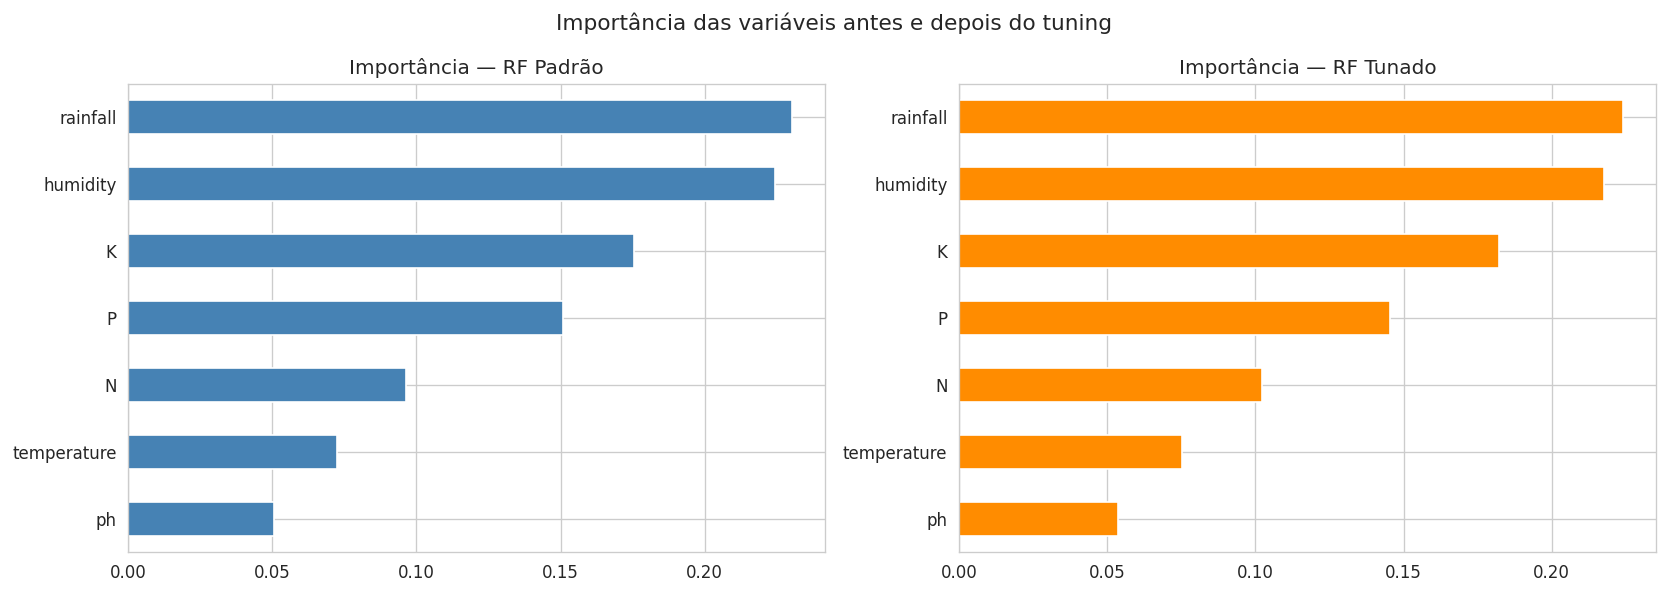

In [38]:
importancias_tunado = pd.Series(
    rf_tunado.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Modelo padrão
pd.Series(modelo.feature_importances_, index=X.columns)\
    .sort_values(ascending=True)\
    .plot(kind='barh', ax=axes[0], color='steelblue', title='Importância — RF Padrão')

# Modelo tunado
importancias_tunado.plot(
    kind='barh', ax=axes[1],
    color='darkorange', title='Importância — RF Tunado'
)

plt.suptitle('Importância das variáveis antes e depois do tuning', fontsize=13)
plt.tight_layout()
plt.show()

### 🛠️ Tuning de Redes Neurais: Busca Manual com Validação Cruzada

O `scikeras` apresenta incompatibilidade com versões recentes do scikit-learn
(`AttributeError: 'super' object has no attribute '__sklearn_tags__'`).

A solução adotada é implementar um **loop manual de busca aleatória** com
`StratifiedKFold`, replicando o comportamento do `RandomizedSearchCV` sem
depender de wrappers externos. Isso garante:

- ✅ Compatibilidade com qualquer versão do scikit-learn e TensorFlow
- ✅ Controle total sobre o treinamento de cada fold
- ✅ Resultados equivalentes ao `RandomizedSearchCV`


### 🏗️ Função `criar_modelo_tunavel`: Arquitetura de Rede Neural Flexível

Esta célula define uma função, `criar_modelo_tunavel`, que constrói um modelo de Rede Neural Keras. A principal característica é que ela aceita hiperparâmetros como argumentos, permitindo que a arquitetura da rede seja dinamicamente alterada durante o processo de *tuning*.

*   **Parâmetros Personalizáveis**: `neurons_1`, `neurons_2`, `dropout_1`, `dropout_2` e `optimizer` podem ser ajustados. Isso permite explorar diferentes tamanhos de camadas, taxas de *dropout* e otimizadores para encontrar a melhor configuração para o problema.
*   **Camadas Densa (`layers.Dense`)**: Duas camadas ocultas com ativação `relu` para aprender representações complexas dos dados.
*   **Dropout (`layers.Dropout`)**: Camadas de *dropout* são incluídas para prevenir *overfitting*, desativando aleatoriamente neurônios durante o treinamento.
*   **Camada de Saída**: Uma camada `Dense` final com `n_classes` (o número total de culturas) neurônios e ativação `softmax`, que produz probabilidades de cada cultura para a classificação.
*   **Compilação**: O modelo é compilado com um `optimizer` (padrão 'adam'), `sparse_categorical_crossentropy` como função de perda (adequada para rótulos inteiros) e `accuracy` como métrica de avaliação. Esta função é essencial para o `RandomizedSearchCV` posterior.

In [39]:
def criar_modelo_tunavel(
    neurons_1   = 128,
    neurons_2   = 64,
    dropout_1   = 0.3,
    dropout_2   = 0.2,
    optimizer   = 'adam',
    n_classes   = 22
):
    modelo = keras.Sequential([
        layers.Dense(neurons_1, activation='relu',
                     input_shape=(X_train_nn.shape[1],)),
        layers.Dropout(dropout_1),

        layers.Dense(neurons_2, activation='relu'),
        layers.Dropout(dropout_2),

        layers.Dense(32, activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ])

    modelo.compile(
        optimizer = optimizer,
        loss      = 'sparse_categorical_crossentropy',
        metrics   = ['accuracy']
    )
    return modelo

### 🚀 Otimização de Hiperparâmetros: Rede Neural com `RandomizedSearchCV`

Esta célula configura e executa o `RandomizedSearchCV` para otimizar a Rede Neural, usando o `KerasClassifier` como *wrapper* para integrar o modelo Keras com o ecossistema scikit-learn.

*   **`nn_wrapper`**: O `KerasClassifier` encapsula nossa função `criar_modelo_tunavel`, tornando o modelo Keras compatível com a API do scikit-learn. Parâmetros fixos como `epochs` e `batch_size` para cada ajuste são definidos aqui.
*   **`param_dist_nn`**: Define o espaço de busca para os hiperparâmetros da Rede Neural. Inclui o número de neurônios nas duas primeiras camadas (`model__neurons_1`, `model__neurons_2`), as taxas de *dropout* (`model__dropout_1`, `model__dropout_2`), o `optimizer` a ser usado, e o `batch_size` e `epochs` que podem ser explorados.
*   **`n_iter=10`**: Para redes neurais, o *tuning* é computacionalmente mais intensivo, então um número menor de iterações (10) é escolhido.
*   **`cv=3`**: Validação cruzada com 3 *folds*.

O `RandomizedSearchCV` busca a combinação de hiperparâmetros que resulta na melhor acurácia média durante a validação cruzada, e o resultado é impresso no final, mostrando os `best_params_` e a `best_score_`.

In [40]:
import itertools, random

# Espaço de busca (mesmo do original)
param_space = {
    'neurons_1' : [64, 128, 256],
    'neurons_2' : [32, 64, 128],
    'dropout_1' : [0.1, 0.2, 0.3, 0.4],
    'dropout_2' : [0.1, 0.2, 0.3],
    'optimizer' : ['adam', 'rmsprop'],
    'batch_size': [16, 32, 64],
    'epochs'    : [50, 100]
}

N_ITER  = 10   # combinações aleatórias testadas
N_FOLDS = 3    # validação cruzada de 3 folds
random.seed(42)

# Gera N_ITER combinações aleatórias
keys   = list(param_space.keys())
combos = []
seen   = set()
while len(combos) < N_ITER:
    c = tuple(random.choice(param_space[k]) for k in keys)
    if c not in seen:
        seen.add(c)
        combos.append(dict(zip(keys, c)))

# Busca manual com StratifiedKFold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

best_score_nn  = -1
best_params_nn = None
best_model_nn  = None

print(f"Testando {N_ITER} combinações × {N_FOLDS} folds...\n")

for i, params in enumerate(combos, 1):
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_nn, y_train_enc)):
        X_tr, X_val = X_train_nn[tr_idx], X_train_nn[val_idx]
        y_tr, y_val = y_train_enc[tr_idx], y_train_enc[val_idx]

        m = criar_modelo_tunavel(
            neurons_1 = params['neurons_1'],
            neurons_2 = params['neurons_2'],
            dropout_1 = params['dropout_1'],
            dropout_2 = params['dropout_2'],
            optimizer = params['optimizer']
        )
        m.fit(X_tr, y_tr,
              epochs     = params['epochs'],
              batch_size = params['batch_size'],
              verbose    = 0)

        preds = np.argmax(m.predict(X_val, verbose=0), axis=1)
        fold_scores.append(accuracy_score(y_val, preds))

    mean_acc = np.mean(fold_scores)
    print(f"  [{i:02d}/{N_ITER}] acc_cv={mean_acc:.4f} | {params}")

    if mean_acc > best_score_nn:
        best_score_nn  = mean_acc
        best_params_nn = params
        # Retreina com todos os dados de treino para uso posterior
        best_model_nn  = criar_modelo_tunavel(
            neurons_1 = params['neurons_1'],
            neurons_2 = params['neurons_2'],
            dropout_1 = params['dropout_1'],
            dropout_2 = params['dropout_2'],
            optimizer = params['optimizer']
        )
        best_model_nn.fit(X_train_nn, y_train_enc,
                          epochs     = params['epochs'],
                          batch_size = params['batch_size'],
                          verbose    = 0)

print("\n=== RESULTADO DO TUNING — REDE NEURAL ===")
print(f"Melhores parâmetros : {best_params_nn}")
print(f"Melhor acurácia (CV): {best_score_nn*100:.2f}%")


Testando 10 combinações × 3 folds...

  [01/10] acc_cv=0.9733 | {'neurons_1': 256, 'neurons_2': 32, 'dropout_1': 0.1, 'dropout_2': 0.3, 'optimizer': 'rmsprop', 'batch_size': 16, 'epochs': 50}
  [02/10] acc_cv=0.9784 | {'neurons_1': 64, 'neurons_2': 128, 'dropout_1': 0.1, 'dropout_2': 0.3, 'optimizer': 'adam', 'batch_size': 64, 'epochs': 100}
  [03/10] acc_cv=0.9716 | {'neurons_1': 64, 'neurons_2': 32, 'dropout_1': 0.1, 'dropout_2': 0.1, 'optimizer': 'adam', 'batch_size': 64, 'epochs': 50}
  [04/10] acc_cv=0.9790 | {'neurons_1': 256, 'neurons_2': 32, 'dropout_1': 0.4, 'dropout_2': 0.1, 'optimizer': 'rmsprop', 'batch_size': 64, 'epochs': 100}
  [05/10] acc_cv=0.9580 | {'neurons_1': 64, 'neurons_2': 32, 'dropout_1': 0.4, 'dropout_2': 0.2, 'optimizer': 'rmsprop', 'batch_size': 16, 'epochs': 50}
  [06/10] acc_cv=0.9830 | {'neurons_1': 128, 'neurons_2': 32, 'dropout_1': 0.1, 'dropout_2': 0.2, 'optimizer': 'adam', 'batch_size': 32, 'epochs': 100}
  [07/10] acc_cv=0.9670 | {'neurons_1': 256, '

In [41]:
# Avalia o melhor modelo neural tunado no conjunto de teste
y_pred_nn_tunado_enc = np.argmax(best_model_nn.predict(X_test_nn, verbose=0), axis=1)
y_pred_nn_tunado     = le.inverse_transform(y_pred_nn_tunado_enc)
acc_nn_tunado        = accuracy_score(y_test, y_pred_nn_tunado)

print(f"Acurácia Rede Neural padrão : {acc_nn*100:.2f}%")
print(f"Acurácia Rede Neural tunada : {acc_nn_tunado*100:.2f}%")
print(f"Ganho com tuning            : {(acc_nn_tunado - acc_nn)*100:+.2f} p.p.")
print("\n--- Relatório completo (tunado) ---")
print(__import__('sklearn.metrics', fromlist=['classification_report']).classification_report(y_test, y_pred_nn_tunado))


Acurácia Rede Neural padrão : 99.09%
Acurácia Rede Neural tunada : 98.86%
Ganho com tuning            : -0.23 p.p.

--- Relatório completo (tunado) ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.91      1.00      0.95        20
      grapes       1.00      1.00      1.00        20
        jute       1.00      0.90      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.90      0.95        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       1.00      1.00    

### 📊 Avaliação da Rede Neural Tunada

Após o *tuning* de hiperparâmetros da Rede Neural, esta célula avalia o desempenho do modelo otimizado (`nn_search.predict`) no conjunto de teste (`X_test_nn`, `y_test`).

*   **Previsões**: As previsões são obtidas do modelo tunado e convertidas de volta para os rótulos de cultura originais usando `le.inverse_transform`.
*   **Acurácia**: A acurácia do modelo tunado (`acc_nn_tunado`) é calculada e comparada com a acurácia da Rede Neural padrão (`acc_nn`). O `ganho com tuning` é apresentado em pontos percentuais, destacando se a otimização trouxe melhorias significativas.
*   **Relatório de Classificação**: Embora não exibido explicitamente nesta célula, este é o ponto onde normalmente se analisaria o `classification_report` para o modelo tunado, semelhante ao que foi feito para o Random Forest.

In [42]:
# (resultado já calculado na célula anterior)
print(f"Acurácia Rede Neural padrão : {acc_nn*100:.2f}%")
print(f"Acurácia Rede Neural tunada : {acc_nn_tunado*100:.2f}%")
print(f"Ganho com tuning            : {(acc_nn_tunado - acc_nn)*100:+.2f} p.p.")


Acurácia Rede Neural padrão : 99.09%
Acurácia Rede Neural tunada : 98.86%
Ganho com tuning            : -0.23 p.p.


### 🚀 Comparativo Final de Desempenho: Modelos Padrão vs. Tunados

Esta célula fornece uma visão consolidada do desempenho de todos os modelos avaliados neste projeto: Random Forest padrão, Random Forest tunado, Rede Neural padrão e Rede Neural tunada. O objetivo é visualizar o impacto do *tuning* e comparar a eficácia de diferentes abordagens de modelagem.

*   **`modelos_nomes` e `acuracias_todas`**: Listas que contêm os nomes dos modelos e suas respectivas acurácias no conjunto de teste, facilitando a visualização.
*   **Gráfico de Barras**: Um gráfico de barras colorido compara visualmente as acurácias. Rótulos nas barras indicam os valores exatos de acurácia, e uma linha de referência destaca o melhor desempenho geral.

Este gráfico é fundamental para identificar qual modelo e qual estratégia (padrão vs. tunado) ofereceu o melhor resultado para a tarefa de recomendação de culturas.

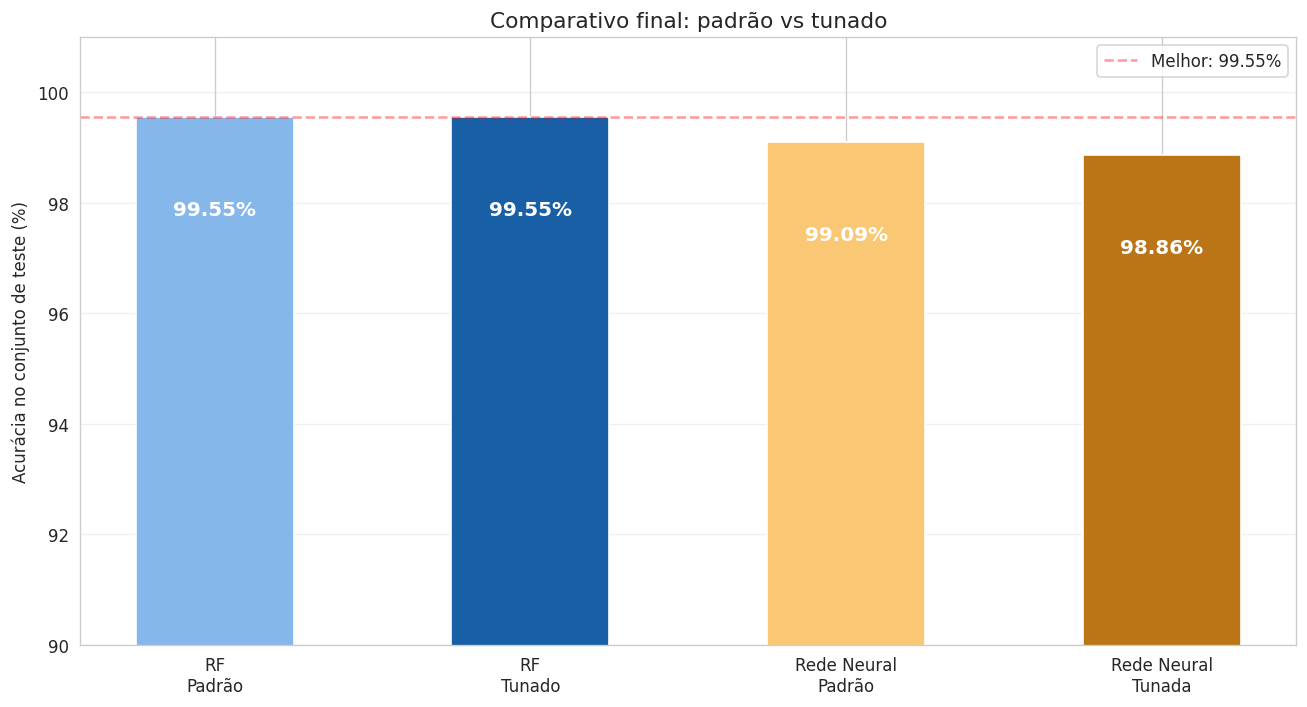

In [43]:
modelos_nomes = [
    'RF\nPadrão',
    'RF\nTunado',
    'Rede Neural\nPadrão',
    'Rede Neural\nTunada'
]

acuracias_todas = [
    acc_rf        * 100,
    acc_rf_tunado * 100,
    acc_nn        * 100,
    acc_nn_tunado * 100
]

cores_barras = ['#85B7EB', '#185FA5', '#FAC775', '#BA7517']

fig, ax = plt.subplots(figsize=(11, 6))
barras  = ax.bar(modelos_nomes, acuracias_todas,
                 color=cores_barras, width=0.5, edgecolor='white')

for barra, val in zip(barras, acuracias_todas):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() - 1.5,
        f'{val:.2f}%',
        ha='center', va='top',
        color='white', fontweight='bold', fontsize=12
    )

ax.set_ylim(90, 101)
ax.set_title('Comparativo final: padrão vs tunado', fontsize=13)
ax.set_ylabel('Acurácia no conjunto de teste (%)')
ax.grid(axis='y', alpha=0.3)

# Linha de referência
ax.axhline(y=max(acuracias_todas), color='red',
           linestyle='--', alpha=0.4, label=f'Melhor: {max(acuracias_todas):.2f}%')
ax.legend()
plt.tight_layout()
plt.show()

### 📝 Resumo Executivo: Visão Geral dos Resultados do Tuning

Resumo resultados do *tuning* para os modelos Random Forest e Rede Neural. É uma tabela que facilita a comparação rápida do desempenho e da aplicação do *tuning*.

*   **`resultados` DataFrame**: Cria um DataFrame que lista cada modelo, sua acurácia correspondente no conjunto de teste e se o *tuning* (`RandomizedSearchCV`) foi aplicado. Isso permite uma visão clara do antes e depois do *tuning* para ambas as arquiteturas de modelo.
*   **Melhor Modelo Geral**: Identifica e imprime o modelo com a maior acurácia, oferecendo uma conclusão direta sobre o vencedor em termos de desempenho.

Este resumo é ideal para uma compreensão rápida dos principais *insights* obtidos durante a fase de otimização dos modelos.

In [44]:
print("=" * 60)
print("       RESUMO EXECUTIVO — SoilInsight")
print("=" * 60)

resultados = pd.DataFrame({
    'Modelo'          : ['Random Forest Padrão', 'Random Forest Tunado',
                         'Rede Neural Padrão',   'Rede Neural Tunada'],
    'Acurácia (%)'    : [f'{acc_rf*100:.2f}',        f'{acc_rf_tunado*100:.2f}',
                         f'{acc_nn*100:.2f}',         f'{acc_nn_tunado*100:.2f}'],
    'Tuning aplicado' : ['Não', 'RandomizedSearchCV',
                         'Não', 'RandomizedSearchCV'],
})

print(resultados.to_string(index=False))
print("=" * 60)
print(f"\nMelhor modelo geral: {resultados.loc[resultados['Acurácia (%)'].astype(float).idxmax(), 'Modelo']}")

       RESUMO EXECUTIVO — SoilInsight
              Modelo Acurácia (%)    Tuning aplicado
Random Forest Padrão        99.55                Não
Random Forest Tunado        99.55 RandomizedSearchCV
  Rede Neural Padrão        99.09                Não
  Rede Neural Tunada        98.86 RandomizedSearchCV

Melhor modelo geral: Random Forest Padrão
